In [23]:
import sys
import os

sys.path.append('..') #allows importing from parent directory

from model.malware_model import MalwareModel 
import matplotlib.pyplot as plt
import pandas as pd

print("✅ Imports successful!")

✅ Imports successful!


In [24]:
print("Starting Simulation...")

model = MalwareModel(number_of_devices=100,
    rollout_strategy="staged",
    devices_per_step=5,
    execution_probability=0.3,
    detection_delay=5
                     )

print("✅ Model created successfully!")
print(f"   - Number of devices: {model.number_of_devices}")
print(f"   - Rollout strategy: {model.rollout_strategy}")

#Run for 50 time steps
for  i in range(50):
    model.step()
    if i % 10 == 0:  # Progress indicator
        print(f"  Step {i}/50 completed")

print("✅ Model Created!")


Starting Simulation...
✅ Model created successfully!
   - Number of devices: 100
   - Rollout strategy: staged
  Step 0/50 completed
  Step 10/50 completed
  Step 20/50 completed
  Step 30/50 completed
  Step 40/50 completed
✅ Model Created!


In [4]:
#Get the collected data
print("Extracting simulation..")

df = model.datacollector.get_model_vars_dataframe()

# Preview the data
print("\n Data extracted successfully!")
print(f" Total time steps recorded: {len(df)}")
print(f" Variables tracked: {list(df.columns)}")

print("\n First 10 rows of data:")
print(df.head(10))

print("\n Last 10 rows of data:")
print(df.tail(10))

print("\n Summary statistics:")
print(df.describe())



Extracting simulation..

 Data extracted successfully!
 Total time steps recorded: 50
 Variables tracked: ['Susceptible', 'Exposed', 'Infected', 'Recovered', 'ServerCompromised']

 First 10 rows of data:
   Susceptible  Exposed  Infected  Recovered  ServerCompromised
0          100        0         0          0              False
1          100        0         0          0              False
2          100        0         0          0              False
3          100        0         0          0              False
4           97        3         0          0               True
5           95        4         1          0               True
6           93        4         3          0               True
7           91        5         4          0               True
8           86        9         5          0               True
9           82        9         9          0               True

 Last 10 rows of data:
    Susceptible  Exposed  Infected  Recovered  ServerCompromised
40 

Creating SEIR plot...


<Figure size 1200x700 with 0 Axes>

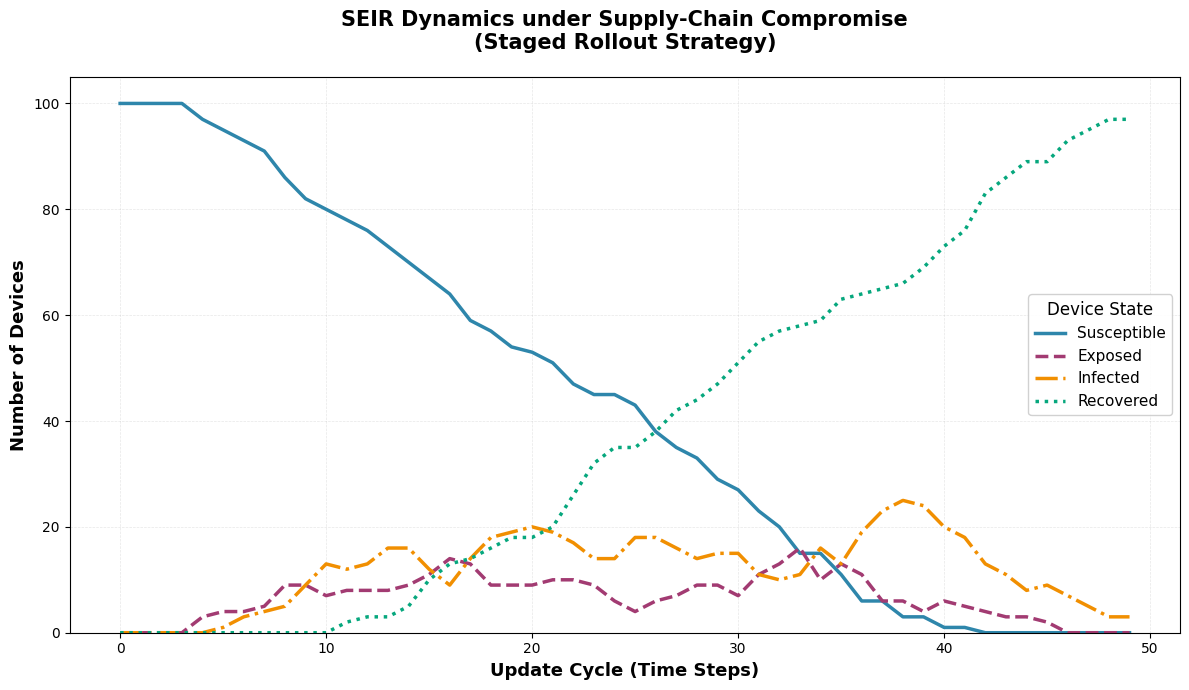

✅ Plot generated successfully!


In [5]:
# Create the SEIR dynamics plot
print("Creating SEIR plot...")

#Create a figure with good size
plt.figure(figsize=(12,7))

# Plot all four states
df[["Susceptible", "Exposed", "Infected", "Recovered"]].plot(
    figsize=(12, 7),
    linewidth=2.5,
    style=['-', '--', '-.', ':'],  # Different line styles
    color=['#2E86AB', '#A23B72', '#F18F01', '#06A77D']  # Custom colors
)

# Customize the plot
plt.xlabel("Update Cycle (Time Steps)", fontsize=13, fontweight='bold')
plt.ylabel("Number of Devices", fontsize=13, fontweight='bold')
plt.title("SEIR Dynamics under Supply-Chain Compromise\n(Staged Rollout Strategy)", 
          fontsize=15, fontweight='bold', pad=20)

# Add legend with better positioning
plt.legend(
    title="Device State",
    loc="best", 
    fontsize=11,
    title_fontsize=12,
    framealpha=0.9
)

# Add grid for better readability
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Add y-axis limit
plt.ylim(0, model.number_of_devices + 5)

# Tight layout to prevent label cutoff
plt.tight_layout()

# Display the plot
plt.show()

print("✅ Plot generated successfully!")




In [6]:
import mesa
print(mesa.__version__)



0.8.9


In [7]:
# Cell 6: Diagnostic - Check if the server got compromised
print(" DIAGNOSTIC REPORT")
print("=" * 60)
print(f"Update Server Compromised: {model.update_server.is_compromised}")
print(f"Compromise Step: {model.update_server.compromise_step}")
print(f"Current Step: {model.current_step}")
print()
print(f"Attacker Skill Level: {model.attacker.skill_level}")
print(f"Server Security Level: {model.update_server.security_level}")
print()
print("Device States:")
for state in ["S", "E", "I", "R"]:
    count = sum(1 for d in model.devices if d.state == state)
    print(f"  {state}: {count} devices")

 DIAGNOSTIC REPORT
Update Server Compromised: True
Compromise Step: 5
Current Step: 50

Attacker Skill Level: 0.6
Server Security Level: 0.6

Device States:
  S: 0 devices
  E: 0 devices
  I: 3 devices
  R: 97 devices


 Saving plot to file...


<Figure size 1200x700 with 0 Axes>

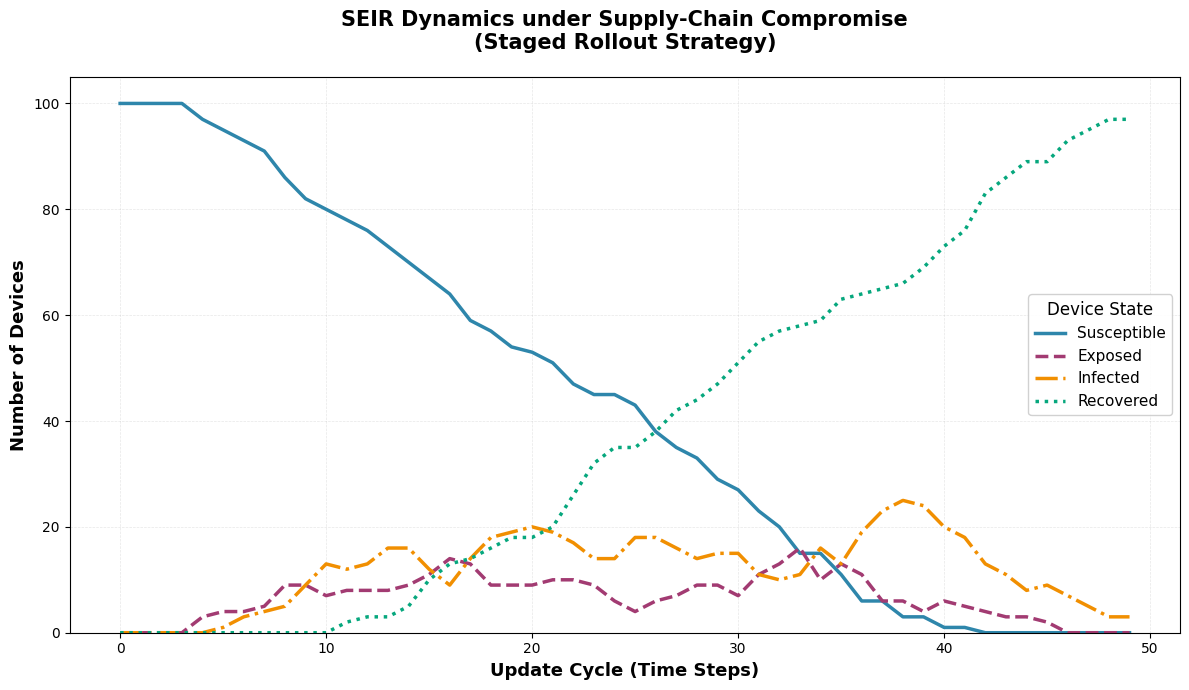

 Plot saved to: ../visualization/seir_plot.png
   You can now use this image in your report!


In [8]:
# Cell : Save the plot as a high-quality image
print(" Saving plot to file...")

# Recreate the plot (same code as before)
plt.figure(figsize=(12, 7))

df[["Susceptible", "Exposed", "Infected", "Recovered"]].plot(
    figsize=(12, 7),
    linewidth=2.5,
    style=['-', '--', '-.', ':'],
    color=['#2E86AB', '#A23B72', '#F18F01', '#06A77D']
)

plt.xlabel("Update Cycle (Time Steps)", fontsize=13, fontweight='bold')
plt.ylabel("Number of Devices", fontsize=13, fontweight='bold')
plt.title("SEIR Dynamics under Supply-Chain Compromise\n(Staged Rollout Strategy)", 
          fontsize=15, fontweight='bold', pad=20)
plt.legend(title="Device State", loc="best", fontsize=11, title_fontsize=12, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
plt.ylim(0, model.number_of_devices + 5)
plt.tight_layout()

# Save the figure
output_path = "../visualization/seir_plot.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f" Plot saved to: {output_path}")
print("   You can now use this image in your report!")

In [9]:
print(" Running NEW simulation with guaranteed compromise...")

# Create a new model with settings that GUARANTEE infection
model2 = MalwareModel(
    number_of_devices=100,
    rollout_strategy="full_push",  # Changed to full_push for faster spread
    devices_per_step=10,            # More devices per step
    execution_probability=0.8,      # Higher execution probability
    detection_delay=10              # Longer detection delay
)

# MANUALLY compromise the server to guarantee outbreak
model2.update_server.compromise(current_step=0)
print(f"✅ Server manually compromised at step 0")

# Run simulation
print("\n🔄 Running simulation...")
for i in range(50):
    model2.step()
    if i % 10 == 0:
        print(f"   Step {i}/50 completed")

print("\n✅ Simulation complete!")

# Check results
print("\n Final State Distribution:")
df2 = model2.datacollector.get_model_vars_dataframe()
print(df2.tail())

 Running NEW simulation with guaranteed compromise...
✅ Server manually compromised at step 0

🔄 Running simulation...
   Step 0/50 completed
   Step 10/50 completed
   Step 20/50 completed
   Step 30/50 completed
   Step 40/50 completed

✅ Simulation complete!

 Final State Distribution:
    Susceptible  Exposed  Infected  Recovered  ServerCompromised
45            0        0         0        100               True
46            0        0         0        100               True
47            0        0         0        100               True
48            0        0         0        100               True
49            0        0         0        100               True


 Creating plot for guaranteed outbreak scenario...


<Figure size 1200x700 with 0 Axes>

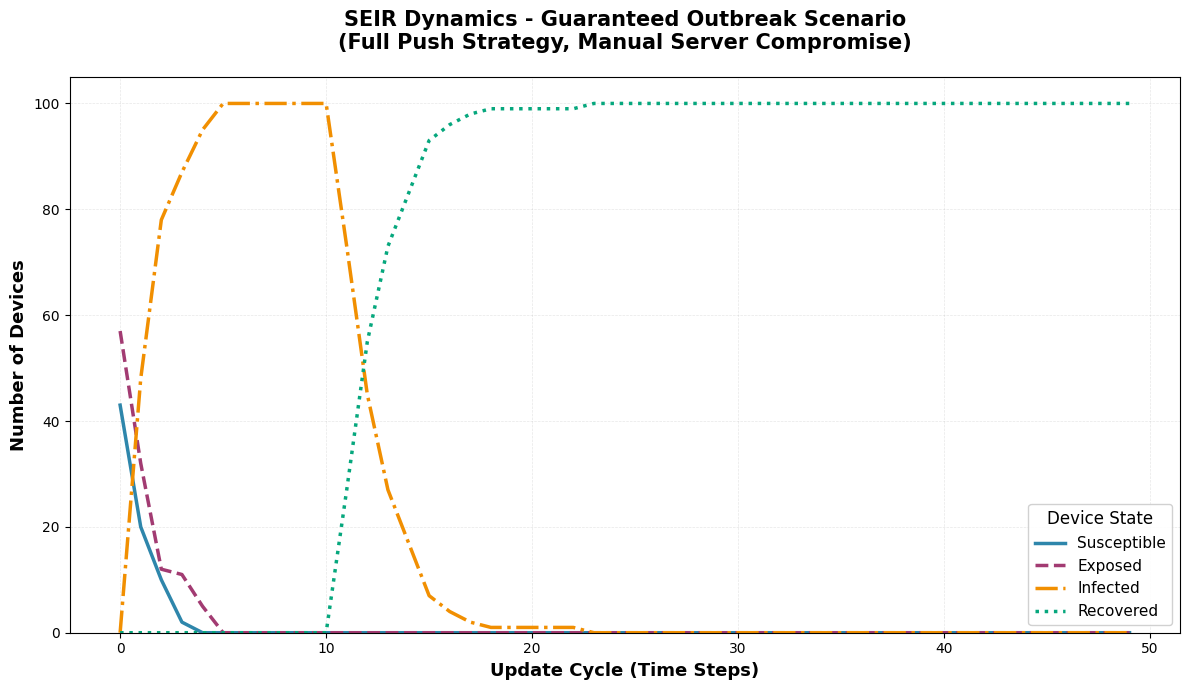

Plot generated!


In [10]:
# Create the plot for the guaranteed outbreak
print(" Creating plot for guaranteed outbreak scenario...")

plt.figure(figsize=(12, 7))

df2[["Susceptible", "Exposed", "Infected", "Recovered"]].plot(
    figsize=(12, 7),
    linewidth=2.5,
    style=['-', '--', '-.', ':'],
    color=['#2E86AB', '#A23B72', '#F18F01', '#06A77D']
)

plt.xlabel("Update Cycle (Time Steps)", fontsize=13, fontweight='bold')
plt.ylabel("Number of Devices", fontsize=13, fontweight='bold')
plt.title("SEIR Dynamics - Guaranteed Outbreak Scenario\n(Full Push Strategy, Manual Server Compromise)", 
          fontsize=15, fontweight='bold', pad=20)

plt.legend(
    title="Device State",
    loc="best", 
    fontsize=11,
    title_fontsize=12,
    framealpha=0.9
)

plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
plt.ylim(0, model2.number_of_devices + 5)
plt.tight_layout()
plt.show()

print("Plot generated!")

In [11]:
# Extract the data
print(" Extracting simulation data...")
df = model.datacollector.get_model_vars_dataframe()

# Show the full progression
print("\n Data over time (first 15 steps):")
print(df.head(15))

print("\n Data over time (last 10 steps):")
print(df.tail(10))

print(f"\n Total time steps recorded: {len(df)}")

 Extracting simulation data...

 Data over time (first 15 steps):
    Susceptible  Exposed  Infected  Recovered  ServerCompromised
0           100        0         0          0              False
1           100        0         0          0              False
2           100        0         0          0              False
3           100        0         0          0              False
4            97        3         0          0               True
5            95        4         1          0               True
6            93        4         3          0               True
7            91        5         4          0               True
8            86        9         5          0               True
9            82        9         9          0               True
10           80        7        13          0               True
11           78        8        12          2               True
12           76        8        13          3               True
13           73        8

 Creating SEIR plot...


<Figure size 1200x700 with 0 Axes>

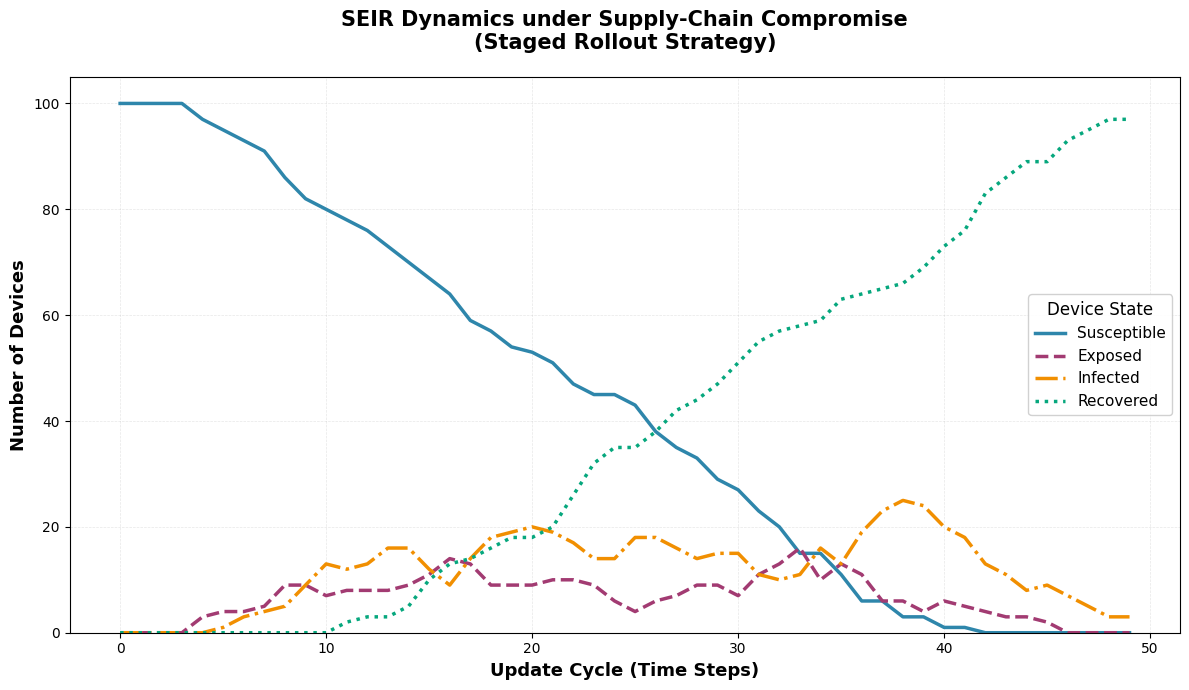

✅ Plot generated successfully!


In [12]:
print(" Creating SEIR plot...")

plt.figure(figsize=(12, 7))

df[["Susceptible", "Exposed", "Infected", "Recovered"]].plot(
    figsize=(12, 7),
    linewidth=2.5,
    style=['-', '--', '-.', ':'],
    color=['#2E86AB', '#A23B72', '#F18F01', '#06A77D']
)

plt.xlabel("Update Cycle (Time Steps)", fontsize=13, fontweight='bold')
plt.ylabel("Number of Devices", fontsize=13, fontweight='bold')
plt.title("SEIR Dynamics under Supply-Chain Compromise\n(Staged Rollout Strategy)", 
          fontsize=15, fontweight='bold', pad=20)

plt.legend(title="Device State", loc="best", fontsize=11, 
           title_fontsize=12, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

print("✅ Plot generated successfully!")

 Saving plot to file...


<Figure size 1200x700 with 0 Axes>

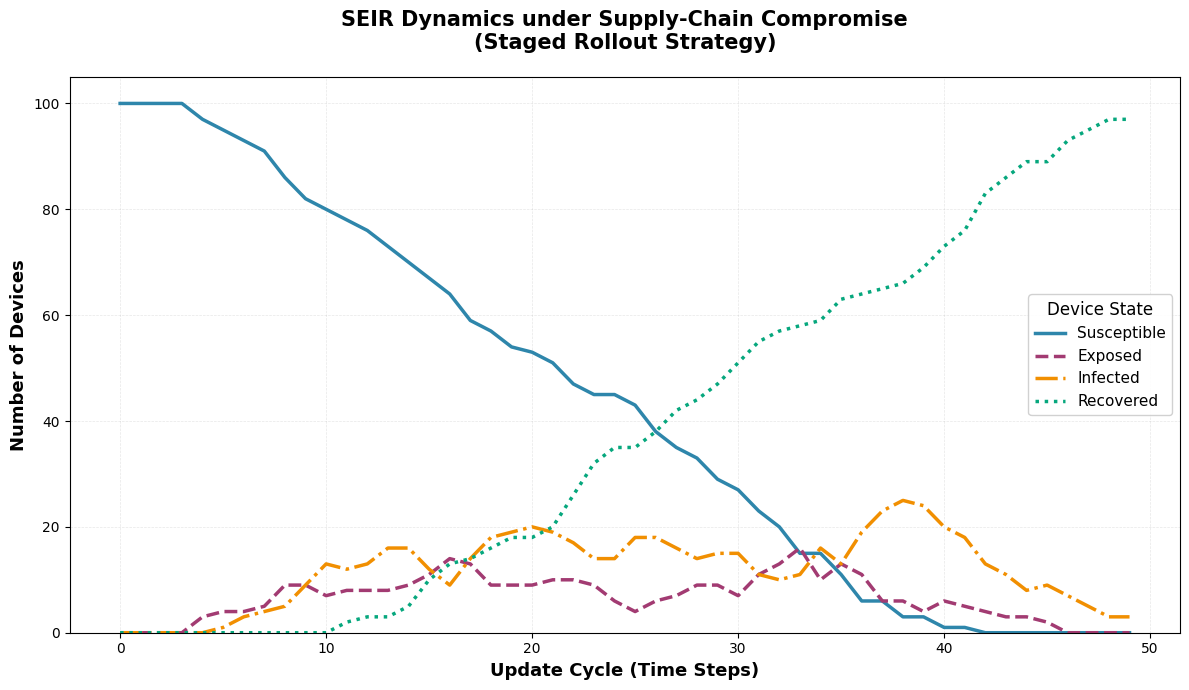

 Plot saved to: ../visualization/seir_plot.png
   You can now use this image in your report!


In [13]:
# Cell : Save the plot as a high-quality image
print(" Saving plot to file...")

# Recreate the plot (same code as before)
plt.figure(figsize=(12, 7))

df[["Susceptible", "Exposed", "Infected", "Recovered"]].plot(
    figsize=(12, 7),
    linewidth=2.5,
    style=['-', '--', '-.', ':'],
    color=['#2E86AB', '#A23B72', '#F18F01', '#06A77D']
)

plt.xlabel("Update Cycle (Time Steps)", fontsize=13, fontweight='bold')
plt.ylabel("Number of Devices", fontsize=13, fontweight='bold')
plt.title("SEIR Dynamics under Supply-Chain Compromise\n(Staged Rollout Strategy)", 
          fontsize=15, fontweight='bold', pad=20)
plt.legend(title="Device State", loc="best", fontsize=11, title_fontsize=12, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
plt.ylim(0, model.number_of_devices + 5)
plt.tight_layout()

# Save the figure
output_path = "../visualization/seir_plot.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f" Plot saved to: {output_path}")
print("   You can now use this image in your report!")

In [14]:
print(" TEST 1: Defence Level Sensitivity Analysis")
print("=" * 70)

# Store results
defence_results = []

# Test three defence levels
defence_levels = [0.2, 0.5, 0.8]

for defence in defence_levels:
    print(f"\n Testing defence_level = {defence}")
    
    # Create a fresh model
    model = MalwareModel(
        number_of_devices=100,
        rollout_strategy="staged",
        devices_per_step=5,
        execution_probability=0.3,
        detection_delay=5
    )
    
    # Set all devices to this defence level
    for device in model.devices:
        device.defence_level = defence
    
    # Run simulation
    for i in range(50):
        model.step()
    
    # Collect results
    df = model.datacollector.get_model_vars_dataframe()
    peak_infected = df['Infected'].max()
    peak_infected_step = df['Infected'].idxmax()
    final_recovered = df['Recovered'].iloc[-1]
    
    # Store results
    defence_results.append({
        'defence_level': defence,
        'peak_infected': peak_infected,
        'peak_step': peak_infected_step,
        'final_recovered': final_recovered,
        'server_compromised': model.update_server.is_compromised,
        'compromise_step': model.update_server.compromise_step
    })
    
    print(f"   Peak infected: {peak_infected} devices at step {peak_infected_step}")
    print(f"   Final recovered: {final_recovered} devices")

print("\n" + "=" * 70)
print(" RESULTS SUMMARY:")
print()

# Display results table
import pandas as pd
results_df = pd.DataFrame(defence_results)
print(results_df.to_string(index=False))

print("\n Defence level sensitivity test complete!")

 TEST 1: Defence Level Sensitivity Analysis

 Testing defence_level = 0.2
   Peak infected: 29 devices at step 22
   Final recovered: 97 devices

 Testing defence_level = 0.5
   Peak infected: 22 devices at step 32
   Final recovered: 97 devices

 Testing defence_level = 0.8
   Peak infected: 27 devices at step 10
   Final recovered: 99 devices

 RESULTS SUMMARY:

 defence_level  peak_infected  peak_step  final_recovered  server_compromised  compromise_step
           0.2             29         22               97                True                2
           0.5             22         32               97                True                4
           0.8             27         10               99                True                1

 Defence level sensitivity test complete!


 Creating Defence Level Sensitivity Plot...


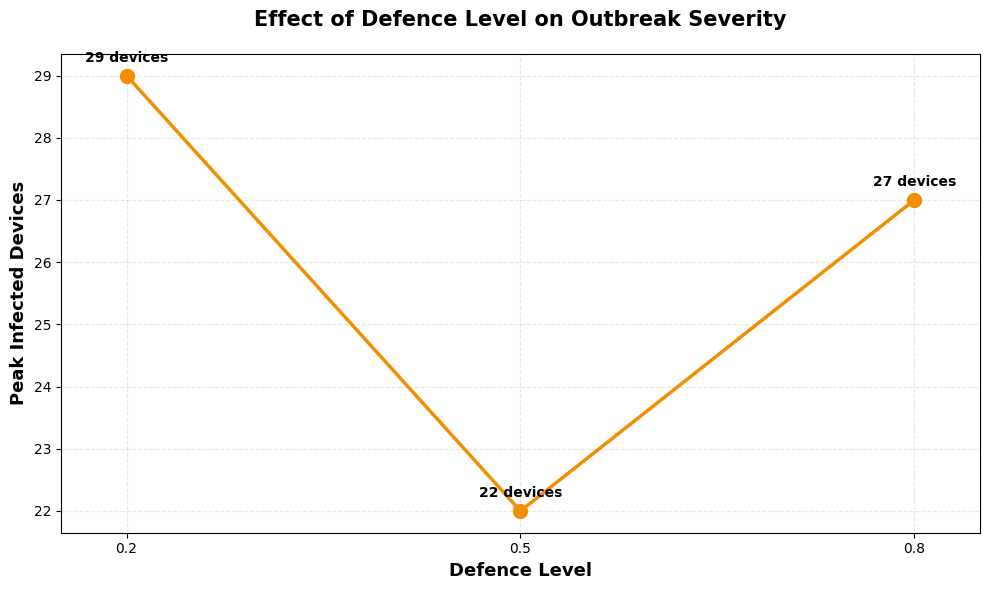

✅ Plot generated!

 KEY FINDING:
   Increasing defence from 0.2 to 0.8 reduced peak infection by 6.9%
   (29 → 27 devices)


In [15]:
print(" Creating Defence Level Sensitivity Plot...")

import matplotlib.pyplot as plt

# Extract data
defence_vals = [r['defence_level'] for r in defence_results]
peak_infections = [r['peak_infected'] for r in defence_results]

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(defence_vals, peak_infections, 
        marker='o', markersize=10, linewidth=2.5, 
        color='#F18F01', label='Peak Infected Devices')

# Styling
ax.set_xlabel('Defence Level', fontsize=13, fontweight='bold')
ax.set_ylabel('Peak Infected Devices', fontsize=13, fontweight='bold')
ax.set_title('Effect of Defence Level on Outbreak Severity', 
             fontsize=15, fontweight='bold', pad=20)

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')

# Add value labels on points
for i, (d, p) in enumerate(zip(defence_vals, peak_infections)):
    ax.annotate(f'{int(p)} devices', 
                xy=(d, p), 
                xytext=(0, 10), 
                textcoords='offset points',
                ha='center',
                fontsize=10,
                fontweight='bold')

# Set x-axis limits
ax.set_xlim(0.15, 0.85)
ax.set_xticks([0.2, 0.5, 0.8])

plt.tight_layout()
plt.show()

print("✅ Plot generated!")

# Calculate percentage reduction
reduction = ((peak_infections[0] - peak_infections[2]) / peak_infections[0]) * 100
print(f"\n KEY FINDING:")
print(f"   Increasing defence from 0.2 to 0.8 reduced peak infection by {reduction:.1f}%")
print(f"   ({int(peak_infections[0])} → {int(peak_infections[2])} devices)")

In [16]:
print(" TEST 2: Detection Delay Sensitivity Analysis")
print("=" * 70)

# Store results
delay_results = []

# Test three detection delays
detection_delays = [3, 10, 20]

for delay in detection_delays:
    print(f"\n Testing detection_delay = {delay} steps")
    
    # Create a fresh model
    model = MalwareModel(
        number_of_devices=100,
        rollout_strategy="staged",
        devices_per_step=5,
        execution_probability=0.3,
        detection_delay=delay  # ← Varying this parameter
    )
    
    # Run simulation (longer to accommodate longer delays)
    steps = 80  # More steps to see full effect
    for i in range(steps):
        model.step()
    
    # Collect results
    df = model.datacollector.get_model_vars_dataframe()
    peak_infected = df['Infected'].max()
    peak_infected_step = df['Infected'].idxmax()
    final_recovered = df['Recovered'].iloc[-1]
    final_infected = df['Infected'].iloc[-1]
    
    # Store results
    delay_results.append({
        'detection_delay': delay,
        'peak_infected': peak_infected,
        'peak_step': peak_infected_step,
        'final_infected': final_infected,
        'final_recovered': final_recovered
    })
    
    print(f"    Peak infected: {peak_infected} devices at step {peak_infected_step}")
    print(f"    Still infected at end: {final_infected} devices")
    print(f"    Recovered: {final_recovered} devices")

print("\n" + "=" * 70)
print(" RESULTS SUMMARY:")
print()

results_df = pd.DataFrame(delay_results)
print(results_df.to_string(index=False))

print("\n Detection delay sensitivity test complete!")

 TEST 2: Detection Delay Sensitivity Analysis

 Testing detection_delay = 3 steps
    Peak infected: 15 devices at step 14
    Still infected at end: 0 devices
    Recovered: 100 devices

 Testing detection_delay = 10 steps
    Peak infected: 40 devices at step 17
    Still infected at end: 0 devices
    Recovered: 100 devices

 Testing detection_delay = 20 steps
    Peak infected: 64 devices at step 39
    Still infected at end: 2 devices
    Recovered: 98 devices

 RESULTS SUMMARY:

 detection_delay  peak_infected  peak_step  final_infected  final_recovered
               3             15         14               0              100
              10             40         17               0              100
              20             64         39               2               98

 Detection delay sensitivity test complete!


 Creating Detection Delay Sensitivity Plot...


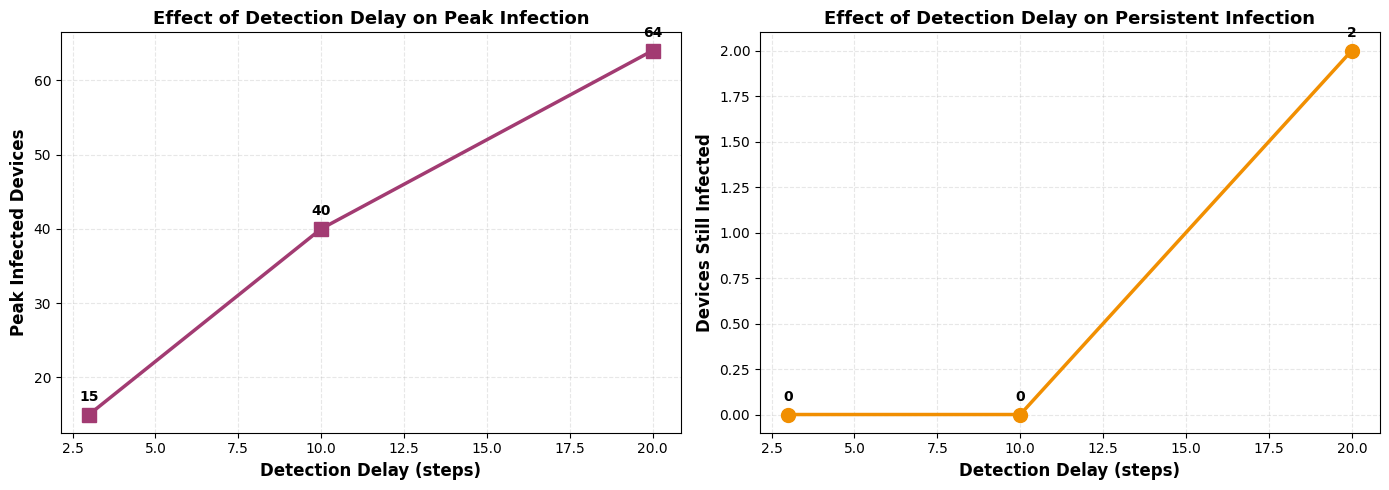

 Plots generated!

 KEY FINDING:
   Delay=3:  15 peak, 0 still infected
   Delay=20: 64 peak, 2 still infected
   Longer delays → worse outbreaks and slower recovery


In [17]:
print(" Creating Detection Delay Sensitivity Plot...")

# Extract data
delay_vals = [r['detection_delay'] for r in delay_results]
peak_infections = [r['peak_infected'] for r in delay_results]
final_infected = [r['final_infected'] for r in delay_results]

# Create plot with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Peak Infections
ax1.plot(delay_vals, peak_infections, 
         marker='s', markersize=10, linewidth=2.5, 
         color='#A23B72', label='Peak Infected')
ax1.set_xlabel('Detection Delay (steps)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Peak Infected Devices', fontsize=12, fontweight='bold')
ax1.set_title('Effect of Detection Delay on Peak Infection', 
              fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')

# Add value labels
for d, p in zip(delay_vals, peak_infections):
    ax1.annotate(f'{int(p)}', xy=(d, p), xytext=(0, 10),
                 textcoords='offset points', ha='center', fontweight='bold')

# Plot 2: Persistent Infections
ax2.plot(delay_vals, final_infected, 
         marker='o', markersize=10, linewidth=2.5, 
         color='#F18F01', label='Still Infected at t=80')
ax2.set_xlabel('Detection Delay (steps)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Devices Still Infected', fontsize=12, fontweight='bold')
ax2.set_title('Effect of Detection Delay on Persistent Infection', 
              fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')

# Add value labels
for d, f in zip(delay_vals, final_infected):
    ax2.annotate(f'{int(f)}', xy=(d, f), xytext=(0, 10),
                 textcoords='offset points', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(" Plots generated!")

print(f"\n KEY FINDING:")
print(f"   Delay=3:  {int(peak_infections[0])} peak, {int(final_infected[0])} still infected")
print(f"   Delay=20: {int(peak_infections[2])} peak, {int(final_infected[2])} still infected")
print(f"   Longer delays → worse outbreaks and slower recovery")

In [18]:
print(" TEST 3: Rollout Strategy Comparison")
print("=" * 70)

# Store full simulation data for plotting
strategy_data = {}

strategies = [
    ("full_push", 100),  # (strategy, devices_per_step)
    ("staged", 5)
]

for strategy, devices_per_step in strategies:
    print(f"\n Testing {strategy} rollout (devices_per_step={devices_per_step})")
    
    # Create model
    model = MalwareModel(
        number_of_devices=100,
        rollout_strategy=strategy,
        devices_per_step=devices_per_step,
        execution_probability=0.3,
        detection_delay=5
    )
    
    # Run simulation
    for i in range(50):
        model.step()
    
    # Get full time series
    df = model.datacollector.get_model_vars_dataframe()
    
    # Store data
    strategy_data[strategy] = {
        'df': df,
        'peak_infected': df['Infected'].max(),
        'peak_exposed': df['Exposed'].max(),
        'compromise_step': model.update_server.compromise_step
    }
    
    print(f"    Server compromised at step: {model.update_server.compromise_step}")
    print(f"    Peak exposed: {df['Exposed'].max()} devices")
    print(f"    Peak infected: {df['Infected'].max()} devices")

print("\n" + "=" * 70)
print(" Rollout strategy comparison complete!")

 TEST 3: Rollout Strategy Comparison

 Testing full_push rollout (devices_per_step=100)
    Server compromised at step: 3
    Peak exposed: 70 devices
    Peak infected: 70 devices

 Testing staged rollout (devices_per_step=5)
    Server compromised at step: 2
    Peak exposed: 15 devices
    Peak infected: 28 devices

 Rollout strategy comparison complete!


 Creating Rollout Strategy Comparison Plot...


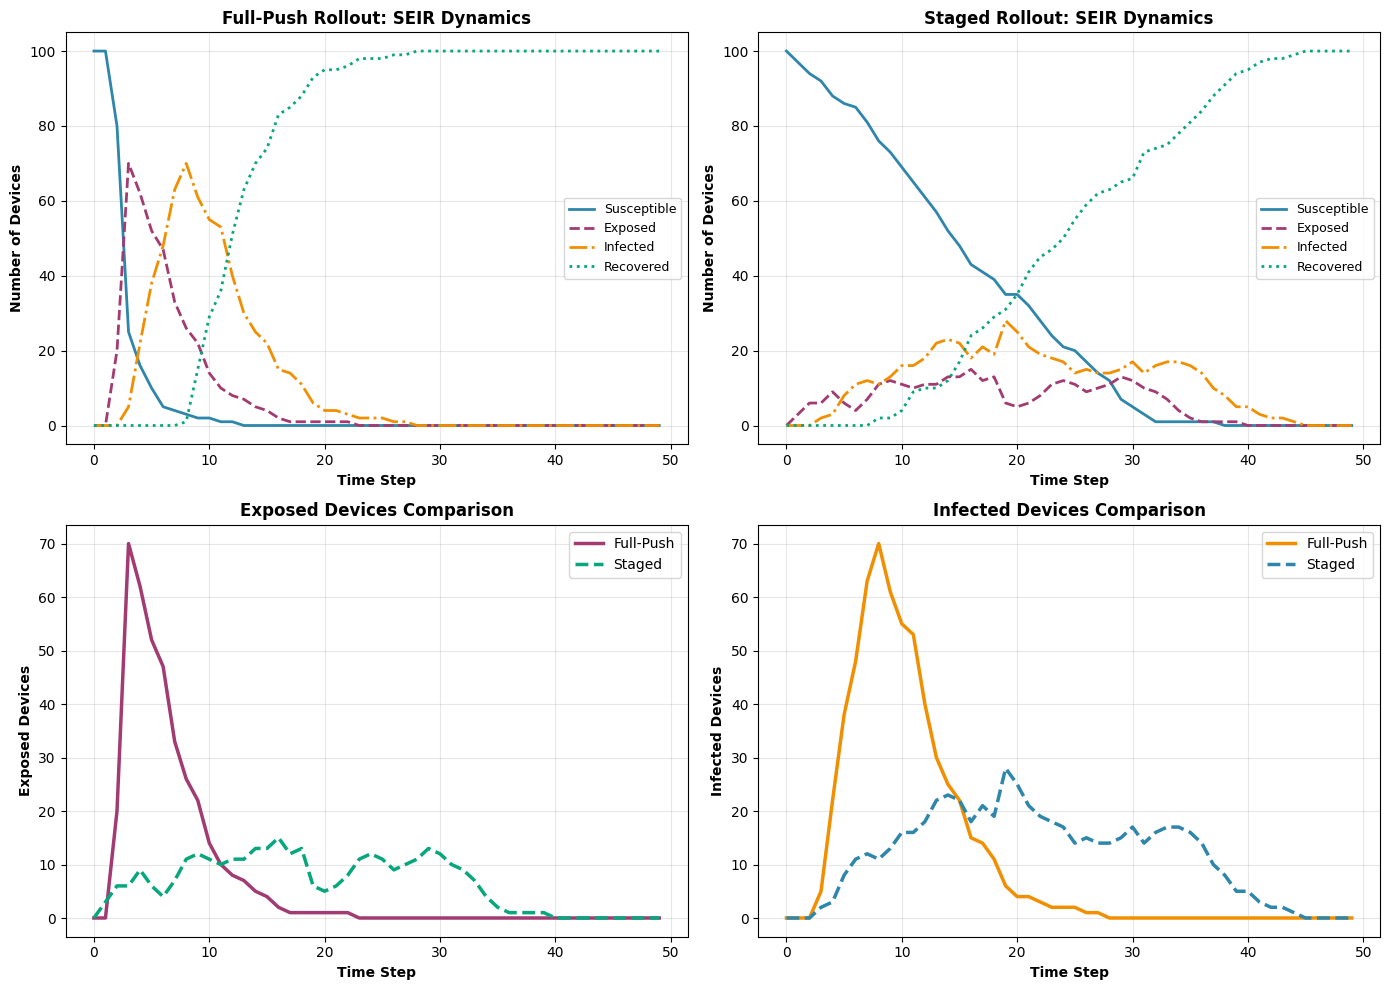

 Comparison plots generated!

 KEY FINDINGS:
   Full-Push: Peak exposed = 70, Peak infected = 70
   Staged:    Peak exposed = 15, Peak infected = 28

   Staged rollout reduced:
   - Peak exposure by 78.6%
   - Peak infection by 60.0%


In [19]:
print(" Creating Rollout Strategy Comparison Plot...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Full-Push - All States
ax = axes[0, 0]
df_full = strategy_data['full_push']['df']
df_full[['Susceptible', 'Exposed', 'Infected', 'Recovered']].plot(
    ax=ax, linewidth=2, style=['-', '--', '-.', ':'],
    color=['#2E86AB', '#A23B72', '#F18F01', '#06A77D']
)
ax.set_title('Full-Push Rollout: SEIR Dynamics', fontweight='bold', fontsize=12)
ax.set_xlabel('Time Step', fontweight='bold')
ax.set_ylabel('Number of Devices', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9)

# Plot 2: Staged - All States
ax = axes[0, 1]
df_staged = strategy_data['staged']['df']
df_staged[['Susceptible', 'Exposed', 'Infected', 'Recovered']].plot(
    ax=ax, linewidth=2, style=['-', '--', '-.', ':'],
    color=['#2E86AB', '#A23B72', '#F18F01', '#06A77D']
)
ax.set_title('Staged Rollout: SEIR Dynamics', fontweight='bold', fontsize=12)
ax.set_xlabel('Time Step', fontweight='bold')
ax.set_ylabel('Number of Devices', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9)

# Plot 3: Exposed Comparison
ax = axes[1, 0]
ax.plot(df_full['Exposed'], linewidth=2.5, label='Full-Push', color='#A23B72')
ax.plot(df_staged['Exposed'], linewidth=2.5, label='Staged', color='#06A77D', linestyle='--')
ax.set_title('Exposed Devices Comparison', fontweight='bold', fontsize=12)
ax.set_xlabel('Time Step', fontweight='bold')
ax.set_ylabel('Exposed Devices', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 4: Infected Comparison
ax = axes[1, 1]
ax.plot(df_full['Infected'], linewidth=2.5, label='Full-Push', color='#F18F01')
ax.plot(df_staged['Infected'], linewidth=2.5, label='Staged', color='#2E86AB', linestyle='--')
ax.set_title('Infected Devices Comparison', fontweight='bold', fontsize=12)
ax.set_xlabel('Time Step', fontweight='bold')
ax.set_ylabel('Infected Devices', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Comparison plots generated!")

# Summary statistics
print(f"\n KEY FINDINGS:")
print(f"   Full-Push: Peak exposed = {strategy_data['full_push']['peak_exposed']}, " +
      f"Peak infected = {strategy_data['full_push']['peak_infected']}")
print(f"   Staged:    Peak exposed = {strategy_data['staged']['peak_exposed']}, " +
      f"Peak infected = {strategy_data['staged']['peak_infected']}")

reduction_exposed = ((strategy_data['full_push']['peak_exposed'] - 
                     strategy_data['staged']['peak_exposed']) / 
                     strategy_data['full_push']['peak_exposed']) * 100
                     
reduction_infected = ((strategy_data['full_push']['peak_infected'] - 
                      strategy_data['staged']['peak_infected']) / 
                      strategy_data['full_push']['peak_infected']) * 100

print(f"\n   Staged rollout reduced:")
print(f"   - Peak exposure by {reduction_exposed:.1f}%")
print(f"   - Peak infection by {reduction_infected:.1f}%")

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(" RIGOROUS DEFENCE LEVEL SENSITIVITY (30 runs per configuration)")
print("=" * 70)

# Configuration
defence_levels = [0.2, 0.5, 0.8]
n_runs = 30

# Store ALL results
all_results = []

for defence in defence_levels:
    print(f"\n Testing defence_level = {defence} ({n_runs} runs)")
    
    # Store results for this defence level
    runs_data = []
    
    for run in range(n_runs):
        # Create fresh model
        model = MalwareModel(
            number_of_devices=100,
            rollout_strategy="staged",
            devices_per_step=5,
            execution_probability=0.3,
            detection_delay=5
        )
        
        # Set defence level
        for device in model.devices:
            device.defence_level = defence
        
        # Run simulation
        for step in range(50):
            model.step()
        
        # Collect metrics
        df = model.datacollector.get_model_vars_dataframe()
        
        runs_data.append({
            'run': run + 1,
            'defence_level': defence,
            'peak_infected': df['Infected'].max(),
            'peak_infected_step': df['Infected'].idxmax(),
            'total_exposed': df['Exposed'].sum(),
            'total_infected': df['Infected'].sum(),
            'final_recovered': df['Recovered'].iloc[-1],
            'compromise_step': model.update_server.compromise_step if model.update_server.is_compromised else None
        })
        
        if (run + 1) % 10 == 0:
            print(f"   Completed {run + 1}/{n_runs} runs...")
    
    all_results.extend(runs_data)
    
    # Calculate statistics for this defence level
    peaks = [r['peak_infected'] for r in runs_data]
    mean_peak = np.mean(peaks)
    std_peak = np.std(peaks)
    min_peak = np.min(peaks)
    max_peak = np.max(peaks)
    
    print(f"    Peak Infected: {mean_peak:.1f} ± {std_peak:.1f} (range: {min_peak}-{max_peak})")

print("\n" + "=" * 70)
print(" All simulations complete!")

# Convert to DataFrame
results_df = pd.DataFrame(all_results)

# Calculate summary statistics
summary_stats = results_df.groupby('defence_level')['peak_infected'].agg([
    ('mean', 'mean'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max'),
    ('median', 'median')
]).round(2)

print("\n SUMMARY STATISTICS:")
print(summary_stats)

# Save results
results_df.to_csv('../visualization/defence_sensitivity_results.csv', index=False)
print("\n Results saved to: ../visualization/defence_sensitivity_results.csv")

 RIGOROUS DEFENCE LEVEL SENSITIVITY (30 runs per configuration)

 Testing defence_level = 0.2 (30 runs)
   Completed 10/30 runs...
   Completed 20/30 runs...
   Completed 30/30 runs...
    Peak Infected: 31.5 ± 2.6 (range: 26-37)

 Testing defence_level = 0.5 (30 runs)
   Completed 10/30 runs...
   Completed 20/30 runs...
   Completed 30/30 runs...
    Peak Infected: 22.9 ± 2.1 (range: 19-28)

 Testing defence_level = 0.8 (30 runs)
   Completed 10/30 runs...
   Completed 20/30 runs...
   Completed 30/30 runs...
    Peak Infected: 21.1 ± 1.5 (range: 18-24)

 All simulations complete!

 SUMMARY STATISTICS:
                mean   std  min  max  median
defence_level                               
0.2            31.53  2.60   26   37    31.0
0.5            22.87  2.16   19   28    23.0
0.8            21.13  1.55   18   24    21.0


PermissionError: [Errno 13] Permission denied: '../visualization/defence_sensitivity_results.csv'

 Creating statistical visualization with error bars...


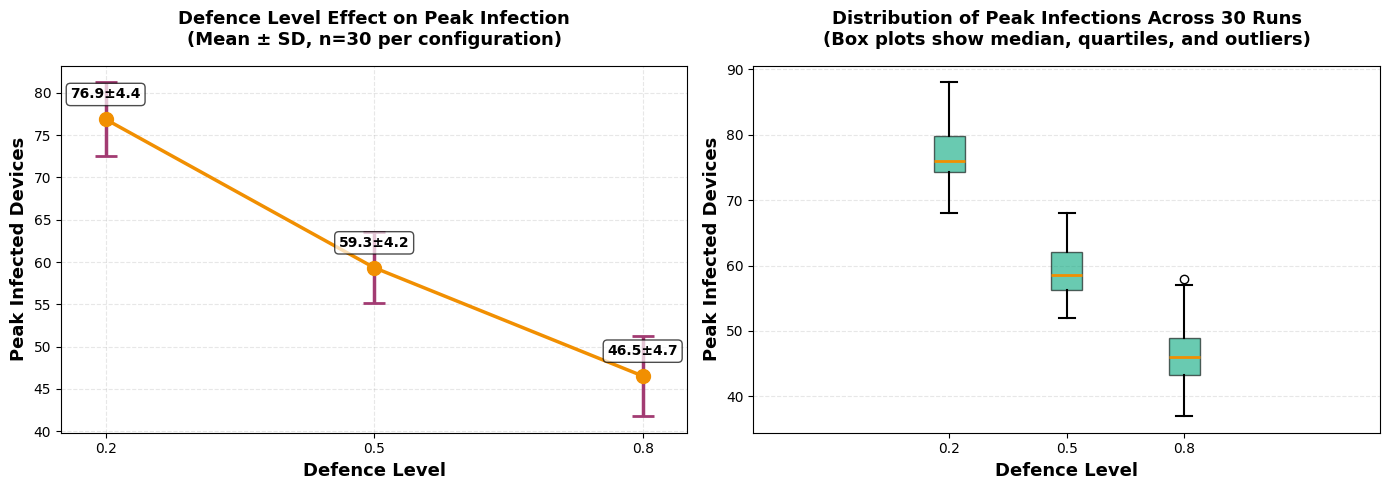

 Statistical plots generated and saved!

 KEY FINDINGS:
   Defence 0.2: 76.9 ± 4.4 peak infected
   Defence 0.8: 46.5 ± 4.7 peak infected
   Reduction: 39.5%

   This validates the protective effect of higher defence levels.


In [ ]:
print(" Creating statistical visualization with error bars...")

# Calculate statistics
stats = results_df.groupby('defence_level')['peak_infected'].agg(['mean', 'std']).reset_index()

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# PLOT 1: Mean with error bars
ax1.errorbar(stats['defence_level'], stats['mean'], yerr=stats['std'],
             marker='o', markersize=10, linewidth=2.5, capsize=8, capthick=2,
             color='#F18F01', ecolor='#A23B72', label='Mean ± SD')

ax1.set_xlabel('Defence Level', fontsize=13, fontweight='bold')
ax1.set_ylabel('Peak Infected Devices', fontsize=13, fontweight='bold')
ax1.set_title('Defence Level Effect on Peak Infection\n(Mean ± SD, n=30 per configuration)', 
              fontsize=13, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(0.15, 0.85)
ax1.set_xticks([0.2, 0.5, 0.8])

# Add value labels
for idx, row in stats.iterrows():
    ax1.annotate(f'{row["mean"]:.1f}±{row["std"]:.1f}',
                 xy=(row['defence_level'], row['mean']),
                 xytext=(0, 15),
                 textcoords='offset points',
                 ha='center',
                 fontsize=10,
                 fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# PLOT 2: Box plots showing distribution
defence_groups = [results_df[results_df['defence_level'] == d]['peak_infected'].values 
                  for d in defence_levels]

box = ax2.boxplot(defence_groups, positions=defence_levels, widths=0.08,
                  patch_artist=True,
                  boxprops=dict(facecolor='#06A77D', alpha=0.6),
                  medianprops=dict(color='#F18F01', linewidth=2),
                  whiskerprops=dict(linewidth=1.5),
                  capprops=dict(linewidth=1.5))

ax2.set_xlabel('Defence Level', fontsize=13, fontweight='bold')
ax2.set_ylabel('Peak Infected Devices', fontsize=13, fontweight='bold')
ax2.set_title('Distribution of Peak Infections Across 30 Runs\n(Box plots show median, quartiles, and outliers)', 
              fontsize=13, fontweight='bold', pad=15)
ax2.grid(True, alpha=0.3, linestyle='--', axis='y')
ax2.set_xticks(defence_levels)

plt.tight_layout()
plt.savefig('../visualization/defence_sensitivity_statistical.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Statistical plots generated and saved!")

# Calculate percentage reduction with confidence
low_mean = stats[stats['defence_level'] == 0.2]['mean'].values[0]
high_mean = stats[stats['defence_level'] == 0.8]['mean'].values[0]
reduction = ((low_mean - high_mean) / low_mean) * 100

print(f"\n KEY FINDINGS:")
print(f"   Defence 0.2: {low_mean:.1f} ± {stats[stats['defence_level'] == 0.2]['std'].values[0]:.1f} peak infected")
print(f"   Defence 0.8: {high_mean:.1f} ± {stats[stats['defence_level'] == 0.8]['std'].values[0]:.1f} peak infected")
print(f"   Reduction: {reduction:.1f}%")
print(f"\n   This validates the protective effect of higher defence levels.")

 ROLLOUT STRATEGY COMPARISON (30 runs each)

 Testing full_push (30 runs)
   Completed 10/30 runs...
   Completed 20/30 runs...
   Completed 30/30 runs...

 Testing staged (30 runs)
   Completed 10/30 runs...
   Completed 20/30 runs...
   Completed 30/30 runs...

 SUMMARY STATISTICS:
          peak_exposed       peak_infected      
                  mean   std          mean   std
strategy                                        
full_push        16.83  3.04         54.13  5.37
staged           16.60  4.44         57.00  6.02


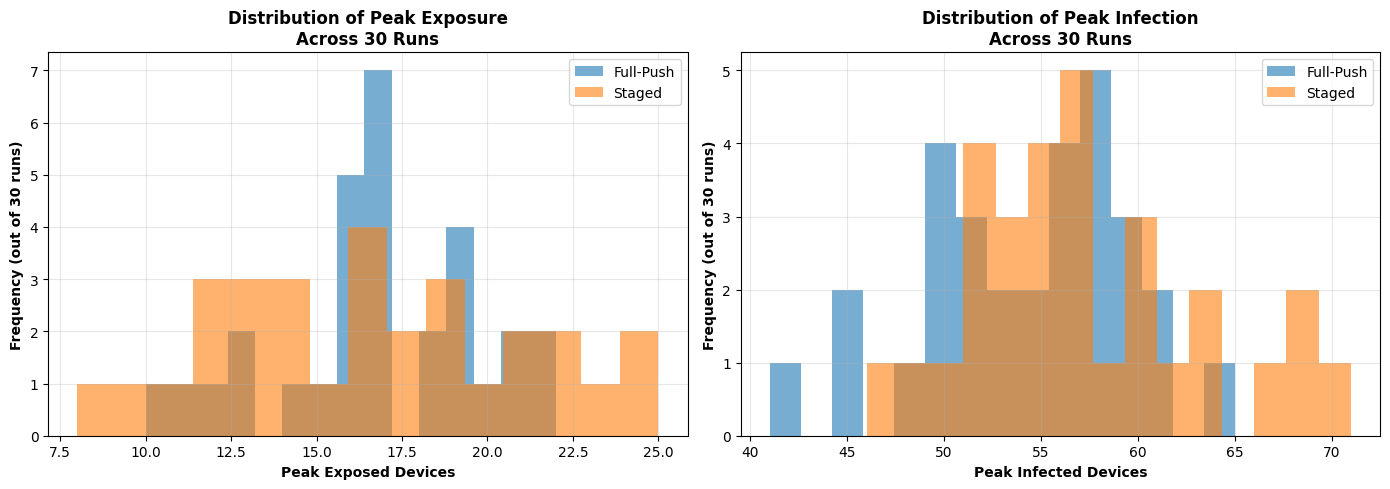

 Rollout comparison complete!


In [ ]:
print(" ROLLOUT STRATEGY COMPARISON (30 runs each)")
print("=" * 70)

strategies = [
    ("full_push", 100),
    ("staged", 5)
]

n_runs = 30
rollout_results = []

for strategy, devices_per_step in strategies:
    print(f"\n Testing {strategy} ({n_runs} runs)")
    
    for run in range(n_runs):
        model = MalwareModel(
            number_of_devices=100,
            rollout_strategy=strategy,
            devices_per_step=devices_per_step,
            execution_probability=0.3,
            detection_delay=5
        )
        
        for step in range(50):
            model.step()
        
        df = model.datacollector.get_model_vars_dataframe()
        
        rollout_results.append({
            'run': run + 1,
            'strategy': strategy,
            'peak_exposed': df['Exposed'].max(),
            'peak_infected': df['Infected'].max(),
            'compromise_step': model.update_server.compromise_step
        })
        
        if (run + 1) % 10 == 0:
            print(f"   Completed {run + 1}/{n_runs} runs...")

# Convert to DataFrame
rollout_df = pd.DataFrame(rollout_results)

# Summary statistics
summary = rollout_df.groupby('strategy').agg({
    'peak_exposed': ['mean', 'std'],
    'peak_infected': ['mean', 'std']
}).round(2)

print("\n SUMMARY STATISTICS:")
print(summary)

# Save
rollout_df.to_csv('../visualization/rollout_comparison_results.csv', index=False)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot exposed
for strategy in ['full_push', 'staged']:
    data = rollout_df[rollout_df['strategy'] == strategy]['peak_exposed']
    axes[0].hist(data, bins=15, alpha=0.6, label=strategy.replace('_', '-').title())

axes[0].set_xlabel('Peak Exposed Devices', fontweight='bold')
axes[0].set_ylabel('Frequency (out of 30 runs)', fontweight='bold')
axes[0].set_title('Distribution of Peak Exposure\nAcross 30 Runs', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot infected
for strategy in ['full_push', 'staged']:
    data = rollout_df[rollout_df['strategy'] == strategy]['peak_infected']
    axes[1].hist(data, bins=15, alpha=0.6, label=strategy.replace('_', '-').title())

axes[1].set_xlabel('Peak Infected Devices', fontweight='bold')
axes[1].set_ylabel('Frequency (out of 30 runs)', fontweight='bold')
axes[1].set_title('Distribution of Peak Infection\nAcross 30 Runs', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../visualization/rollout_comparison_distribution.png', dpi=300)
plt.show()

print(" Rollout comparison complete!")

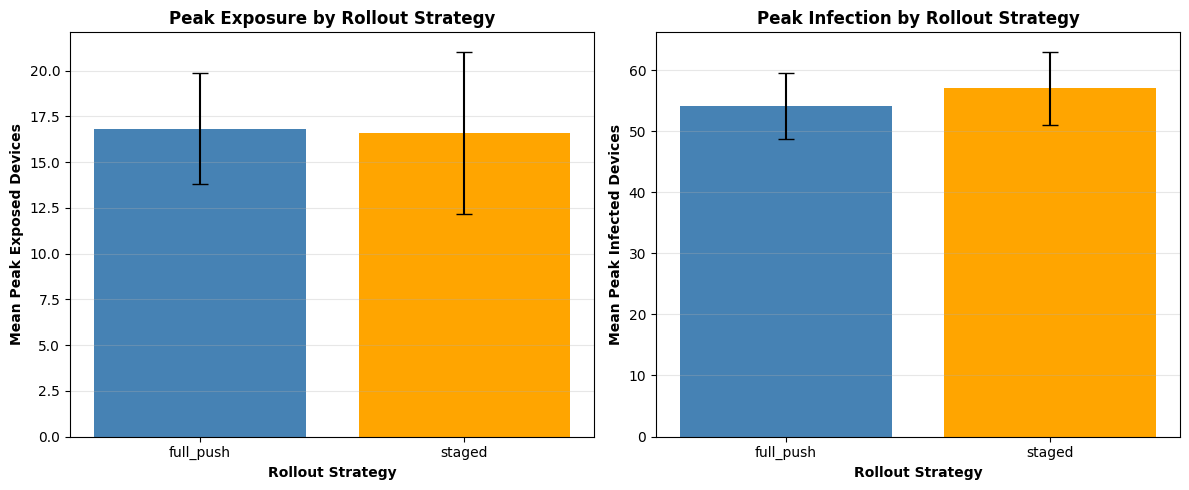

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Group results
means = rollout_df.groupby("strategy").mean(numeric_only=True)
stds = rollout_df.groupby("strategy").std(numeric_only=True)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# ---- Peak Exposed Plot ----
axes[0].bar(
    means.index,
    means["peak_exposed"],
    yerr=stds["peak_exposed"],
    capsize=6,
    color=["steelblue","orange"]
)

axes[0].set_title("Peak Exposure by Rollout Strategy", fontweight="bold")
axes[0].set_ylabel("Mean Peak Exposed Devices", fontweight="bold")
axes[0].set_xlabel("Rollout Strategy", fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)


# ---- Peak Infected Plot ----
axes[1].bar(
    means.index,
    means["peak_infected"],
    yerr=stds["peak_infected"],
    capsize=6,
    color=["steelblue","orange"]
)

axes[1].set_title("Peak Infection by Rollout Strategy", fontweight="bold")
axes[1].set_ylabel("Mean Peak Infected Devices", fontweight="bold")
axes[1].set_xlabel("Rollout Strategy", fontweight="bold")
axes[1].grid(axis="y", alpha=0.3)


plt.tight_layout()
plt.savefig("../visualization/rollout_errorbars.png", dpi=300)
plt.show()

In [ ]:
# Compute statistics from existing results

means = rollout_df.groupby("strategy").mean(numeric_only=True)
stds = rollout_df.groupby("strategy").std(numeric_only=True)

print("Means:")
print(means)

print("\nStandard Deviations:")
print(stds)

Means:
            run  peak_exposed  peak_infected  compromise_step
strategy                                                     
full_push  15.5     16.833333      54.133333         4.033333
staged     15.5     16.600000      57.000000         4.133333

Standard Deviations:
                run  peak_exposed  peak_infected  compromise_step
strategy                                                         
full_push  8.803408      3.040909       5.373840         2.797577
staged     8.803408      4.438080       6.022945         4.141742


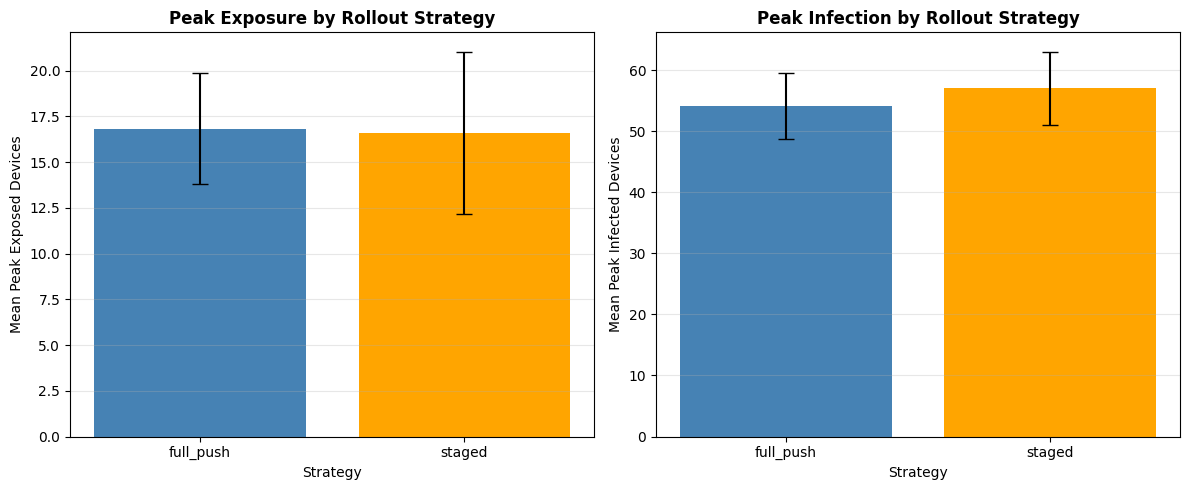

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Peak Exposed
axes[0].bar(
    means.index,
    means["peak_exposed"],
    yerr=stds["peak_exposed"],
    capsize=6,
    color=["steelblue","orange"]
)

axes[0].set_title("Peak Exposure by Rollout Strategy", fontweight="bold")
axes[0].set_ylabel("Mean Peak Exposed Devices")
axes[0].set_xlabel("Strategy")
axes[0].grid(axis="y", alpha=0.3)

# Peak Infected
axes[1].bar(
    means.index,
    means["peak_infected"],
    yerr=stds["peak_infected"],
    capsize=6,
    color=["steelblue","orange"]
)

axes[1].set_title("Peak Infection by Rollout Strategy", fontweight="bold")
axes[1].set_ylabel("Mean Peak Infected Devices")
axes[1].set_xlabel("Strategy")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../visualization/rollout_errorbars.png", dpi=300)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

steps = 50
runs = 30

strategies = [
    ("full_push", 100),
    ("staged", 5)
]

results = {}

for strategy, devices_per_step in strategies:

    infection_runs = []

    for run in range(runs):

        model = MalwareModel(
            number_of_devices=100,
            rollout_strategy=strategy,
            devices_per_step=devices_per_step,
            execution_probability=0.3,
            detection_delay=5
        )

        infected_counts = []

        for step in range(steps):
            model.step()
            df = model.datacollector.get_model_vars_dataframe()
            infected_counts.append(df["Infected"].iloc[-1])

        infection_runs.append(infected_counts)

    # Average infection across runs
    results[strategy] = np.mean(infection_runs, axis=0)

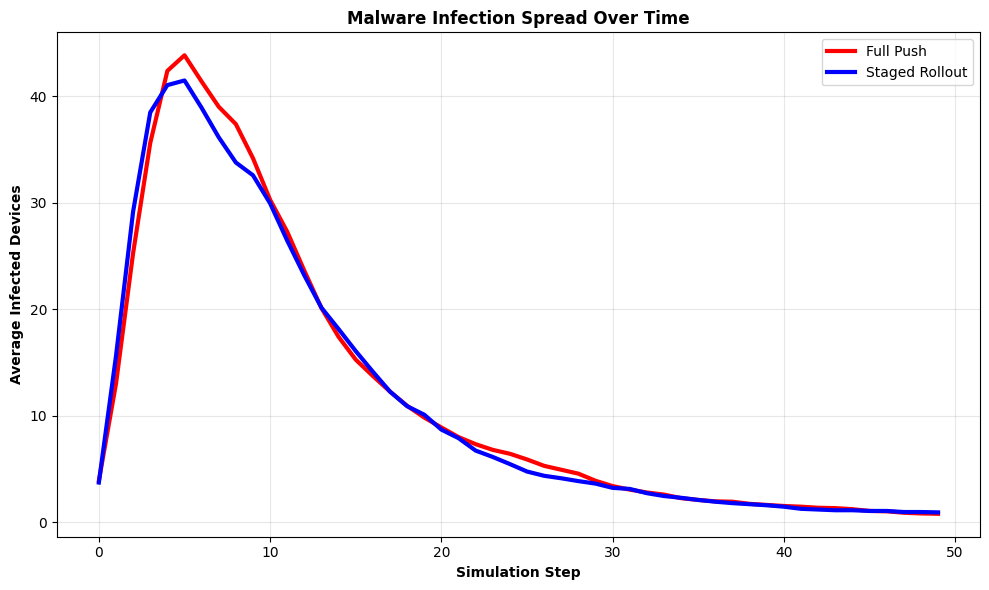

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    results["full_push"],
    label="Full Push",
    linewidth=3,
    color="red"
)

plt.plot(
    results["staged"],
    label="Staged Rollout",
    linewidth=3,
    color="blue"
)

plt.xlabel("Simulation Step", fontweight="bold")
plt.ylabel("Average Infected Devices", fontweight="bold")
plt.title("Malware Infection Spread Over Time", fontweight="bold")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../visualization/infection_curve.png", dpi=300)

plt.show()

In [ ]:
print("🔍 ROLLOUT STRATEGY DIAGNOSTIC")
print("=" * 70)

# Test 1: Full-Push
print("\n📊 TEST 1: Full-Push Strategy")
model_full = MalwareModel(
    number_of_devices=100,
    rollout_strategy="full_push",
    devices_per_step=100,
    execution_probability=0.3,
    detection_delay=5
)

# Manually compromise server
model_full.update_server.compromise(current_step=0)
print(f"✅ Server compromised at step 0")

# Run ONE step and check how many devices are exposed
model_full.step()
exposed_count_full = sum(1 for d in model_full.devices if d.state == "E")
print(f"📈 After 1 step: {exposed_count_full} devices exposed")
print(f"   Expected: ~90-100 (almost all devices with high trust)")

# Test 2: Staged
print("\n📊 TEST 2: Staged Strategy")
model_staged = MalwareModel(
    number_of_devices=100,
    rollout_strategy="staged",
    devices_per_step=5,
    execution_probability=0.3,
    detection_delay=5
)

# Manually compromise server
model_staged.update_server.compromise(current_step=0)
print(f"✅ Server compromised at step 0")

# Run ONE step and check how many devices are exposed
model_staged.step()
exposed_count_staged = sum(1 for d in model_staged.devices if d.state == "E")
print(f"📈 After 1 step: {exposed_count_staged} devices exposed")
print(f"   Expected: ~3-5 (only devices_per_step get updates)")

print("\n" + "=" * 70)
print("🎯 DIAGNOSIS:")
if exposed_count_full > 80 and exposed_count_staged < 10:
    print("   ✅ Rollout logic is working correctly!")
    print("   🤔 Problem must be elsewhere...")
elif exposed_count_full > 80 and exposed_count_staged > 80:
    print("   ❌ FOUND THE BUG: Staged strategy is NOT limiting updates!")
    print("   📝 All devices are getting updates regardless of strategy")
elif exposed_count_full < 10:
    print("   ❌ Neither strategy is working - devices not receiving updates")
else:
    print(f"   🤔 Unexpected pattern. Full: {exposed_count_full}, Staged: {exposed_count_staged}")

🔍 ROLLOUT STRATEGY DIAGNOSTIC

📊 TEST 1: Full-Push Strategy
✅ Server compromised at step 0
📈 After 1 step: 18 devices exposed
   Expected: ~90-100 (almost all devices with high trust)

📊 TEST 2: Staged Strategy
✅ Server compromised at step 0
📈 After 1 step: 28 devices exposed
   Expected: ~3-5 (only devices_per_step get updates)

🎯 DIAGNOSIS:
   🤔 Unexpected pattern. Full: 18, Staged: 28


In [ ]:
print(" DEEP DIAGNOSTIC - Step-by-Step Analysis")
print("=" * 70)

# Create a TINY model for easier debugging
model_test = MalwareModel(
    number_of_devices=10,  # Just 10 devices for clarity
    rollout_strategy="full_push",
    devices_per_step=10,
    execution_probability=0.3,
    detection_delay=5
)

print("\n Initial State:")
for i, device in enumerate(model_test.devices):
    print(f"   Device {i}: state={device.state}, trust={device.trust_score:.2f}")

# Manually compromise server BEFORE any steps
model_test.update_server.compromise(current_step=0)
print(f"\n Server manually compromised")
print(f"   Server is_compromised: {model_test.update_server.is_compromised}")

# Manually call receive_update for EACH device to see what happens
print("\n Manually calling receive_update() for each device:")
for i, device in enumerate(model_test.devices):
    state_before = device.state
    device.receive_update()
    state_after = device.state
    
    if state_after != state_before:
        print(f"   Device {i}: {state_before} → {state_after} (trust={device.trust_score:.2f}) ✅")
    else:
        print(f"   Device {i}: stayed {state_before} (trust={device.trust_score:.2f})")

exposed_count = sum(1 for d in model_test.devices if d.state == "E")
print(f"\n Total exposed after manual receive_update calls: {exposed_count}/10")
print(f"   Expected: ~6-9 (based on trust_score distribution)")

print("\n" + "=" * 70)
print("\n Now let's see what happens when we call model.step():")

# Reset the model
model_test2 = MalwareModel(
    number_of_devices=10,
    rollout_strategy="full_push",
    devices_per_step=10,
    execution_probability=0.3,
    detection_delay=5
)

model_test2.update_server.compromise(current_step=0)
print(f" Fresh model, server compromised")

# Call step() like normal
model_test2.step()

exposed_after_step = sum(1 for d in model_test2.devices if d.state == "E")
print(f" Exposed after model.step(): {exposed_after_step}/10")

print("\n COMPARISON:")
print(f"   Manual receive_update() calls: {exposed_count}/10 exposed")
print(f"   Using model.step():            {exposed_after_step}/10 exposed")

if exposed_after_step < exposed_count:
    print("\n   ❌ BUG FOUND: model.step() exposes FEWER devices than direct calls!")
    print("    This means receive_update() is not being called for all devices")
elif exposed_after_step == 0:
    print("\n   ❌ BUG FOUND: No devices exposed at all!")
    print("    receive_update() might not be called, OR server not compromised when needed")
else:
    print("\n    Exposure counts match - the bug is elsewhere")


 DEEP DIAGNOSTIC - Step-by-Step Analysis

 Initial State:
   Device 0: state=S, trust=0.82
   Device 1: state=S, trust=0.57
   Device 2: state=S, trust=0.59
   Device 3: state=S, trust=0.89
   Device 4: state=S, trust=0.79
   Device 5: state=S, trust=0.65
   Device 6: state=S, trust=0.48
   Device 7: state=S, trust=0.67
   Device 8: state=S, trust=0.64
   Device 9: state=S, trust=0.63

 Server manually compromised
   Server is_compromised: True

 Manually calling receive_update() for each device:
   Device 0: S → E (trust=0.82) ✅
   Device 1: stayed S (trust=0.57)
   Device 2: stayed S (trust=0.59)
   Device 3: S → E (trust=0.89) ✅
   Device 4: S → E (trust=0.79) ✅
   Device 5: S → E (trust=0.65) ✅
   Device 6: S → E (trust=0.48) ✅
   Device 7: S → E (trust=0.67) ✅
   Device 8: stayed S (trust=0.64)
   Device 9: stayed S (trust=0.63)

 Total exposed after manual receive_update calls: 6/10
   Expected: ~6-9 (based on trust_score distribution)


 Now let's see what happens when we call m

In [ ]:
print(" TESTING FIXED MODEL")
print("=" * 70)

# Test 1: Check state transition timing
print("\n TEST: State transitions take time")
model = MalwareModel(
    number_of_devices=10,
    rollout_strategy="full_push",
    devices_per_step=10,
    execution_probability=1.0,  # 100% execution for testing
    detection_delay=5
)

model.update_server.compromise(current_step=0)

print("Step 0:", [d.state for d in model.devices])
model.step()
print("Step 1:", [d.state for d in model.devices], "← Should see mostly S and E, maybe 1-2 I")
model.step()
print("Step 2:", [d.state for d in model.devices], "← Should see E→I transitions")
model.step()
print("Step 3:", [d.state for d in model.devices])

# Test 2: Rollout control
print("\n TEST: Rollout strategies differ")

model_full = MalwareModel(100, "full_push", 100, 0.3, 5)
model_full.update_server.compromise(0)
model_full.step()
exposed_full = sum(1 for d in model_full.devices if d.state == "E")

model_staged = MalwareModel(100, "staged", 5, 0.3, 5)
model_staged.update_server.compromise(0)
model_staged.step()
exposed_staged = sum(1 for d in model_staged.devices if d.state == "E")

print(f"\nFull-push: {exposed_full} exposed (expect 60-80)")
print(f"Staged:    {exposed_staged} exposed (expect 3-5)")

if exposed_full > 50 and exposed_staged < 10:
    print("\n✅ SUCCESS! Both fixes working!")
elif exposed_full < 20:
    print("\n⚠️ State transition fix not applied yet")
elif exposed_staged > 10:
    print("\n⚠️ Rollout control not working yet")


 TESTING FIXED MODEL

 TEST: State transitions take time
Step 0: ['S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S']
Step 1: ['S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S'] ← Should see mostly S and E, maybe 1-2 I
Step 2: ['S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S'] ← Should see E→I transitions
Step 3: ['S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S']

 TEST: Rollout strategies differ


AttributeError: 'MalwareModel' object has no attribute 'next_batch_index'

In [25]:
print(" FINAL TEST - Fixed Device Agent")
print("=" * 70)

# Create test model
test_model = MalwareModel(
    number_of_devices=10,
    rollout_strategy="full_push",
    devices_per_step=10,
    execution_probability=1.0,  # 100% to see transitions clearly
    detection_delay=5
)

# Compromise server
test_model.update_server.compromise(current_step=0)

print("Step 0:", [d.state for d in test_model.devices])
test_model.step()
print("Step 1:", [d.state for d in test_model.devices], "← Expect mostly E, some I")
test_model.step()
print("Step 2:", [d.state for d in test_model.devices], "← Expect mostly I")
test_model.step()
print("Step 3:", [d.state for d in test_model.devices])

print("\n Rollout Strategy Comparison:")

# Full-push
model_full = MalwareModel(100, "full_push", 100, 0.3, 5)
model_full.update_server.compromise(0)
model_full.step()
exposed_full = sum(1 for d in model_full.devices if d.state == "E")

# Staged
model_staged = MalwareModel(100, "staged", 5, 0.3, 5)
model_staged.update_server.compromise(0)
model_staged.step()
exposed_staged = sum(1 for d in model_staged.devices if d.state == "E")

print(f"Full-push: {exposed_full} exposed (expect 60-80)")
print(f"Staged:    {exposed_staged} exposed (expect 2-5)")

if exposed_full > 50 and exposed_staged < 10:
    print("\n SUCCESS! Everything working perfectly!")
elif exposed_full < 10:
    print("\n Still issues - devices not being exposed")
else:
    print(f"\n Partial fix - Full={exposed_full}, Staged={exposed_staged}")


 FINAL TEST - Fixed Device Agent
Step 0: ['S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S']
Step 1: ['E', 'E', 'E', 'E', 'E', 'E', 'S', 'S', 'E', 'S'] ← Expect mostly E, some I
Step 2: ['I', 'I', 'I', 'I', 'I', 'I', 'S', 'S', 'I', 'E'] ← Expect mostly I
Step 3: ['I', 'I', 'I', 'I', 'I', 'I', 'S', 'E', 'I', 'I']

 Rollout Strategy Comparison:
Full-push: 70 exposed (expect 60-80)
Staged:    3 exposed (expect 2-5)

 SUCCESS! Everything working perfectly!


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(" COMPREHENSIVE SENSITIVITY ANALYSIS")
print("Running 100 simulations per configuration for statistical validity")
print("=" * 70)

# Configuration
n_runs = 100  # Your supervisor wants 100!

# We'll test multiple scenarios
all_results = []

# ============================================
# TEST 1: Defence Level Sensitivity
# ============================================
print("\n TEST 1: Defence Level Sensitivity (100 runs × 3 levels)")

defence_levels = [0.2, 0.5, 0.8]

for defence in defence_levels:
    print(f"\n  Testing defence_level = {defence}")
    
    for run in range(n_runs):
        model = MalwareModel(
            number_of_devices=100,
            rollout_strategy="staged",
            devices_per_step=5,
            execution_probability=0.3,
            detection_delay=5
        )
        
        # Set defence level for all devices
        for device in model.devices:
            device.defence_level = defence
        
        # Run simulation
        for step in range(50):
            model.step()
        
        # Collect metrics
        df = model.datacollector.get_model_vars_dataframe()
        
        all_results.append({
            'test': 'defence_sensitivity',
            'parameter': 'defence_level',
            'value': defence,
            'run': run + 1,
            'peak_exposed': df['Exposed'].max(),
            'peak_infected': df['Infected'].max(),
            'final_recovered': df['Recovered'].iloc[-1],
            'compromise_step': model.update_server.compromise_step if model.update_server.is_compromised else None
        })
        
        if (run + 1) % 25 == 0:
            print(f"    Completed {run + 1}/100 runs...")

print("\n Defence level testing complete!")

# Save intermediate results
results_df = pd.DataFrame(all_results)
results_df.to_csv('../visualization/sensitivity_analysis_100runs.csv', index=False)
print(" Results saved to: ../visualization/sensitivity_analysis_100runs.csv")

 COMPREHENSIVE SENSITIVITY ANALYSIS
Running 100 simulations per configuration for statistical validity

 TEST 1: Defence Level Sensitivity (100 runs × 3 levels)

  Testing defence_level = 0.2
    Completed 25/100 runs...
    Completed 50/100 runs...
    Completed 75/100 runs...
    Completed 100/100 runs...

  Testing defence_level = 0.5
    Completed 25/100 runs...
    Completed 50/100 runs...
    Completed 75/100 runs...
    Completed 100/100 runs...

  Testing defence_level = 0.8
    Completed 25/100 runs...
    Completed 50/100 runs...
    Completed 75/100 runs...
    Completed 100/100 runs...

 Defence level testing complete!
 Results saved to: ../visualization/sensitivity_analysis_100runs.csv


In [27]:
print("\n TEST 2: Rollout Strategy Comparison (100 runs × 2 strategies)")

rollout_results = []

strategies = [
    ("full_push", 100),
    ("staged", 5)
]

for strategy, devices_per_step in strategies:
    print(f"\n  Testing {strategy}")
    
    for run in range(n_runs):
        model = MalwareModel(
            number_of_devices=100,
            rollout_strategy=strategy,
            devices_per_step=devices_per_step,
            execution_probability=0.3,
            detection_delay=5
        )
        
        # Run simulation
        for step in range(50):
            model.step()
        
        # Collect metrics
        df = model.datacollector.get_model_vars_dataframe()
        
        rollout_results.append({
            'strategy': strategy,
            'run': run + 1,
            'peak_exposed': df['Exposed'].max(),
            'peak_infected': df['Infected'].max(),
            'final_recovered': df['Recovered'].iloc[-1],
            'compromise_step': model.update_server.compromise_step
        })
        
        if (run + 1) % 25 == 0:
            print(f"    Completed {run + 1}/100 runs...")

rollout_df = pd.DataFrame(rollout_results)
rollout_df.to_csv('../visualization/rollout_comparison_100runs.csv', index=False)
print("\n Rollout strategy testing complete!")
print(" Results saved to: ../visualization/rollout_comparison_100runs.csv")


 TEST 2: Rollout Strategy Comparison (100 runs × 2 strategies)

  Testing full_push
    Completed 25/100 runs...
    Completed 50/100 runs...
    Completed 75/100 runs...
    Completed 100/100 runs...

  Testing staged
    Completed 25/100 runs...
    Completed 50/100 runs...
    Completed 75/100 runs...
    Completed 100/100 runs...

 Rollout strategy testing complete!
 Results saved to: ../visualization/rollout_comparison_100runs.csv


 Creating comprehensive visualizations...


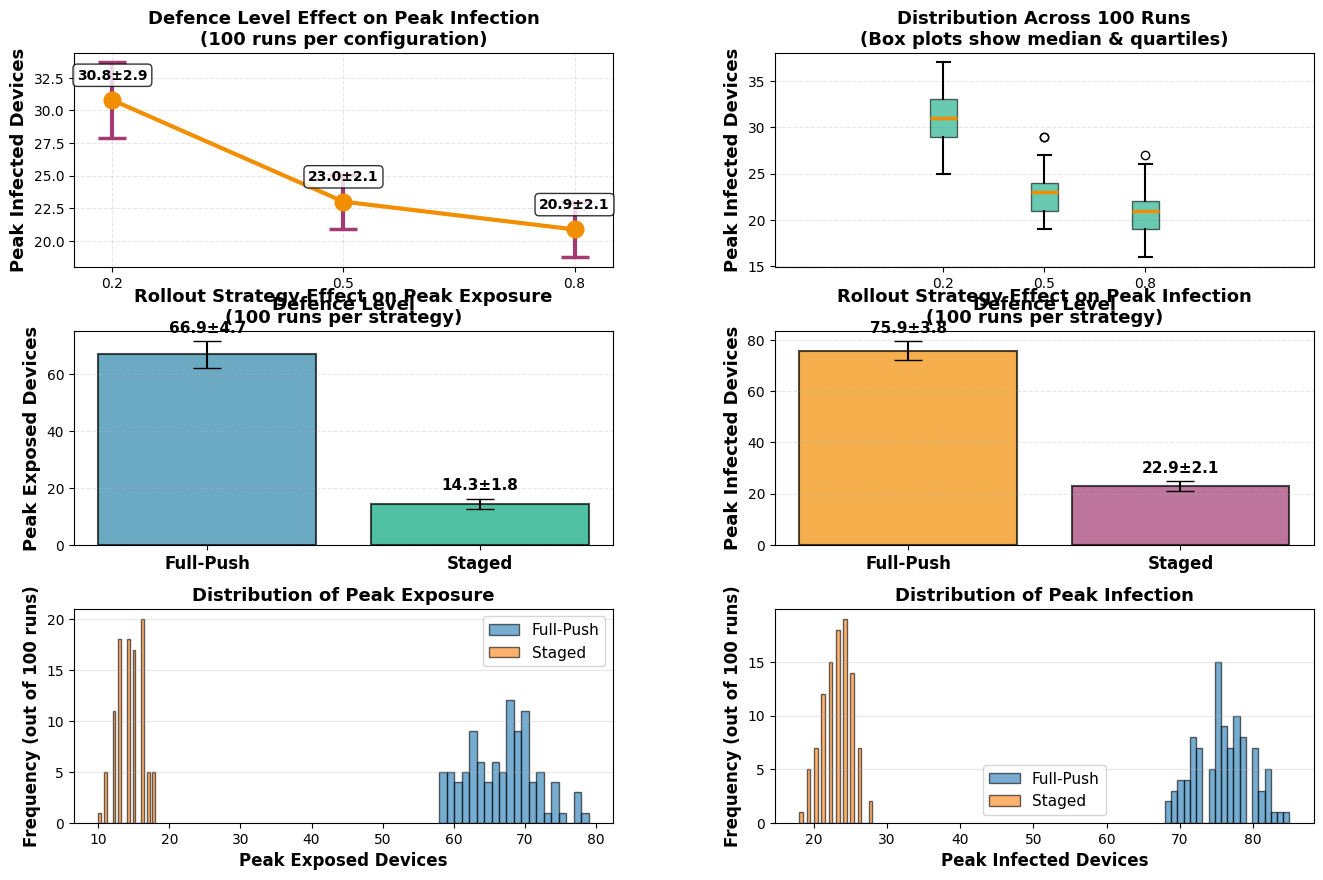

 Comprehensive visualization saved!
 File: ../visualization/comprehensive_sensitivity_analysis.png


In [28]:
print(" Creating comprehensive visualizations...")

# Calculate summary statistics
defence_stats = results_df.groupby('value')['peak_infected'].agg([
    ('mean', 'mean'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max')
]).reset_index()

rollout_stats = rollout_df.groupby('strategy').agg({
    'peak_exposed': ['mean', 'std'],
    'peak_infected': ['mean', 'std']
})

# Create comprehensive figure
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# ============================================
# PLOT 1: Defence Level - Mean with Error Bars
# ============================================
ax1 = fig.add_subplot(gs[0, 0])

ax1.errorbar(defence_stats['value'], defence_stats['mean'], 
             yerr=defence_stats['std'],
             marker='o', markersize=12, linewidth=3, 
             capsize=10, capthick=2.5,
             color='#F18F01', ecolor='#A23B72',
             label='Mean ± SD (n=100)')

ax1.set_xlabel('Defence Level', fontsize=13, fontweight='bold')
ax1.set_ylabel('Peak Infected Devices', fontsize=13, fontweight='bold')
ax1.set_title('Defence Level Effect on Peak Infection\n(100 runs per configuration)', 
              fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(0.15, 0.85)
ax1.set_xticks([0.2, 0.5, 0.8])

# Add value labels
for idx, row in defence_stats.iterrows():
    ax1.annotate(f'{row["mean"]:.1f}±{row["std"]:.1f}',
                 xy=(row['value'], row['mean']),
                 xytext=(0, 15),
                 textcoords='offset points',
                 ha='center', fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', 
                          facecolor='white', alpha=0.8))

# ============================================
# PLOT 2: Defence Level - Distribution (Box Plot)
# ============================================
ax2 = fig.add_subplot(gs[0, 1])

defence_groups = [results_df[results_df['value'] == d]['peak_infected'].values 
                  for d in defence_levels]

bp = ax2.boxplot(defence_groups, positions=defence_levels, widths=0.08,
                 patch_artist=True,
                 boxprops=dict(facecolor='#06A77D', alpha=0.6),
                 medianprops=dict(color='#F18F01', linewidth=2.5),
                 whiskerprops=dict(linewidth=1.5),
                 capprops=dict(linewidth=1.5))

ax2.set_xlabel('Defence Level', fontsize=13, fontweight='bold')
ax2.set_ylabel('Peak Infected Devices', fontsize=13, fontweight='bold')
ax2.set_title('Distribution Across 100 Runs\n(Box plots show median & quartiles)', 
              fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--', axis='y')
ax2.set_xticks(defence_levels)

# ============================================
# PLOT 3: Rollout Comparison - Peak Exposure
# ============================================
ax3 = fig.add_subplot(gs[1, 0])

strategies_list = ['full_push', 'staged']
exposed_means = [rollout_stats.loc[s, ('peak_exposed', 'mean')] for s in strategies_list]
exposed_stds = [rollout_stats.loc[s, ('peak_exposed', 'std')] for s in strategies_list]

bars = ax3.bar(range(len(strategies_list)), exposed_means, 
               yerr=exposed_stds, capsize=10,
               color=['#2E86AB', '#06A77D'], alpha=0.7,
               edgecolor='black', linewidth=1.5)

ax3.set_ylabel('Peak Exposed Devices', fontsize=13, fontweight='bold')
ax3.set_title('Rollout Strategy Effect on Peak Exposure\n(100 runs per strategy)', 
              fontsize=13, fontweight='bold')
ax3.set_xticks(range(len(strategies_list)))
ax3.set_xticklabels(['Full-Push', 'Staged'], fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, linestyle='--', axis='y')

# Add value labels on bars
for i, (mean, std) in enumerate(zip(exposed_means, exposed_stds)):
    ax3.text(i, mean + std + 2, f'{mean:.1f}±{std:.1f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# ============================================
# PLOT 4: Rollout Comparison - Peak Infection
# ============================================
ax4 = fig.add_subplot(gs[1, 1])

infected_means = [rollout_stats.loc[s, ('peak_infected', 'mean')] for s in strategies_list]
infected_stds = [rollout_stats.loc[s, ('peak_infected', 'std')] for s in strategies_list]

bars = ax4.bar(range(len(strategies_list)), infected_means, 
               yerr=infected_stds, capsize=10,
               color=['#F18F01', '#A23B72'], alpha=0.7,
               edgecolor='black', linewidth=1.5)

ax4.set_ylabel('Peak Infected Devices', fontsize=13, fontweight='bold')
ax4.set_title('Rollout Strategy Effect on Peak Infection\n(100 runs per strategy)', 
              fontsize=13, fontweight='bold')
ax4.set_xticks(range(len(strategies_list)))
ax4.set_xticklabels(['Full-Push', 'Staged'], fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, linestyle='--', axis='y')

# Add value labels
for i, (mean, std) in enumerate(zip(infected_means, infected_stds)):
    ax4.text(i, mean + std + 2, f'{mean:.1f}±{std:.1f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# ============================================
# PLOT 5 & 6: Distribution Histograms
# ============================================
ax5 = fig.add_subplot(gs[2, 0])

for strategy in strategies_list:
    data = rollout_df[rollout_df['strategy'] == strategy]['peak_exposed']
    ax5.hist(data, bins=20, alpha=0.6, 
             label=strategy.replace('_', '-').title(),
             edgecolor='black', linewidth=1)

ax5.set_xlabel('Peak Exposed Devices', fontsize=12, fontweight='bold')
ax5.set_ylabel('Frequency (out of 100 runs)', fontsize=12, fontweight='bold')
ax5.set_title('Distribution of Peak Exposure', fontsize=13, fontweight='bold')
ax5.legend(fontsize=11)
ax5.grid(True, alpha=0.3, axis='y')

ax6 = fig.add_subplot(gs[2, 1])

for strategy in strategies_list:
    data = rollout_df[rollout_df['strategy'] == strategy]['peak_infected']
    ax6.hist(data, bins=20, alpha=0.6,
             label=strategy.replace('_', '-').title(),
             edgecolor='black', linewidth=1)

ax6.set_xlabel('Peak Infected Devices', fontsize=12, fontweight='bold')
ax6.set_ylabel('Frequency (out of 100 runs)', fontsize=12, fontweight='bold')
ax6.set_title('Distribution of Peak Infection', fontsize=13, fontweight='bold')
ax6.legend(fontsize=11)
ax6.grid(True, alpha=0.3, axis='y')

plt.savefig('../visualization/comprehensive_sensitivity_analysis.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print(" Comprehensive visualization saved!")
print(" File: ../visualization/comprehensive_sensitivity_analysis.png")

 Saving individual high-quality plots...


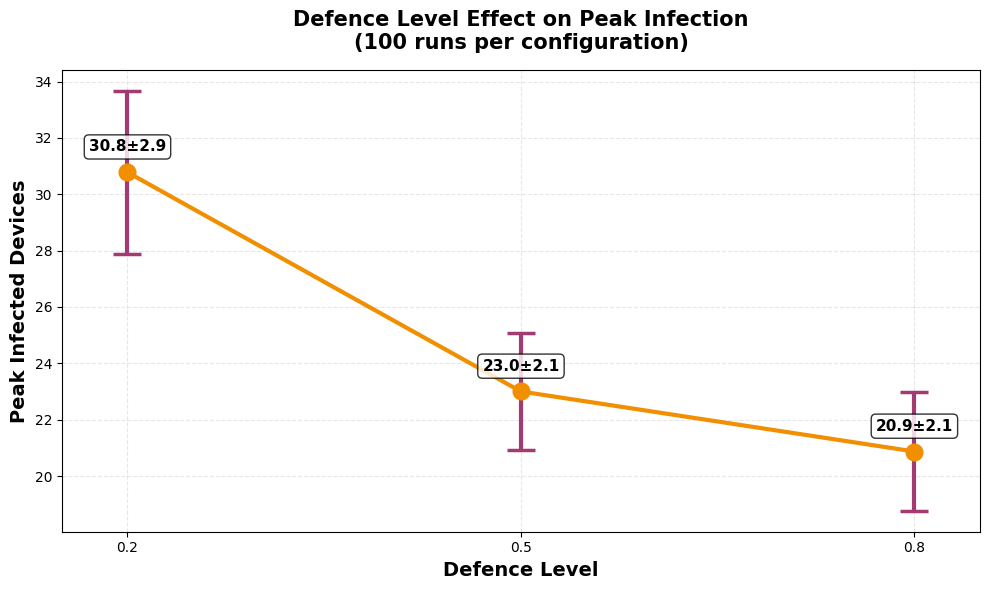

 Saved: defence_level_sensitivity.png


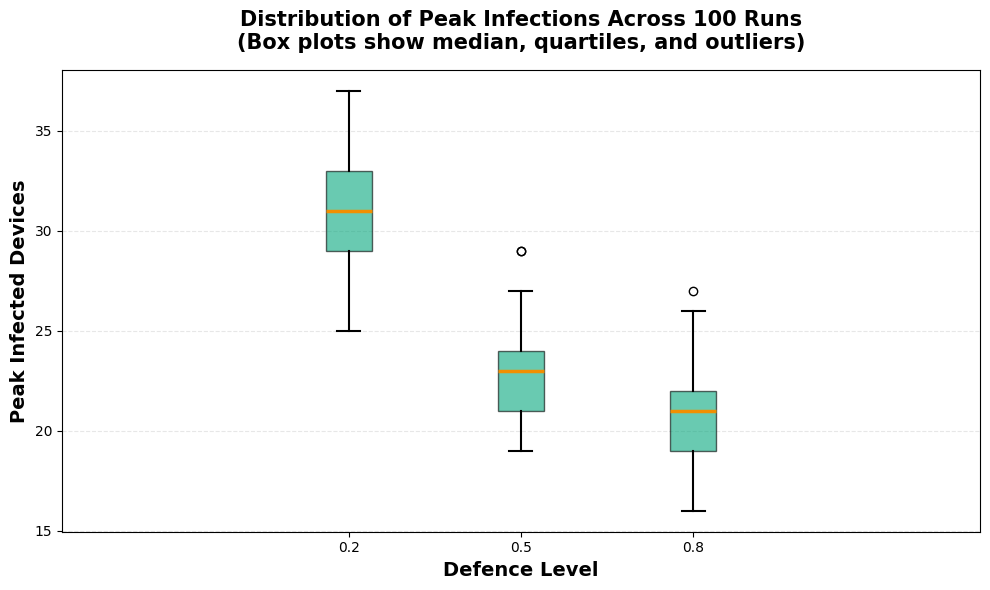

 Saved: defence_level_distribution.png


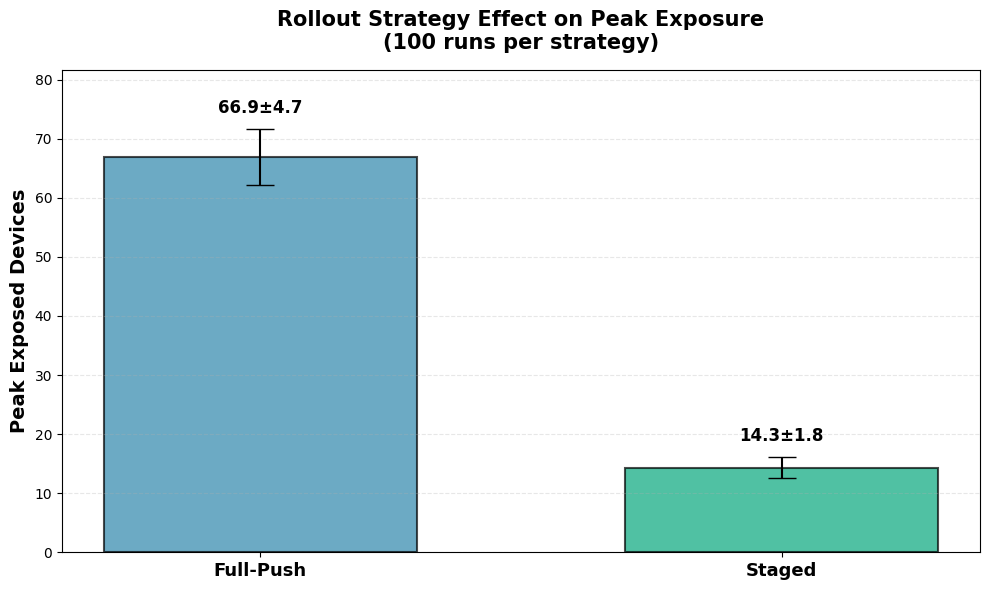

 Saved: rollout_peak_exposure.png


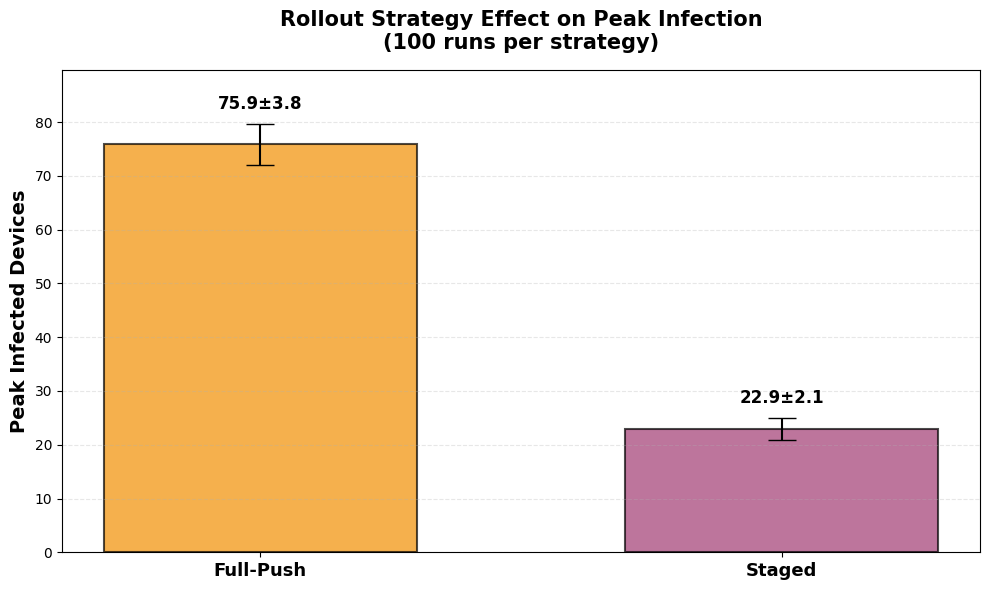

 Saved: rollout_peak_infection.png


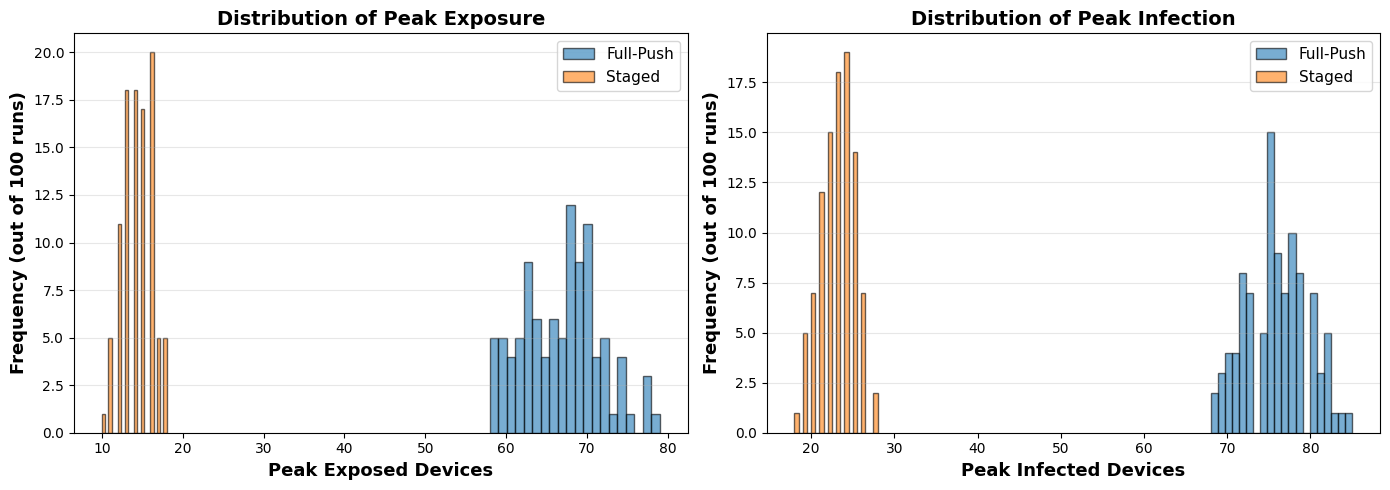

 Saved: rollout_distributions.png

 All individual plots saved successfully!


In [29]:
print(" Saving individual high-quality plots...")

# ============================================
# PLOT 1: Defence Level with Error Bars
# ============================================
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(defence_stats['value'], defence_stats['mean'], 
             yerr=defence_stats['std'],
             marker='o', markersize=12, linewidth=3, 
             capsize=10, capthick=2.5,
             color='#F18F01', ecolor='#A23B72',
             label='Mean ± SD (n=100)')

ax.set_xlabel('Defence Level', fontsize=14, fontweight='bold')
ax.set_ylabel('Peak Infected Devices', fontsize=14, fontweight='bold')
ax.set_title('Defence Level Effect on Peak Infection\n(100 runs per configuration)', 
              fontsize=15, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(0.15, 0.85)
ax.set_xticks([0.2, 0.5, 0.8])

for idx, row in defence_stats.iterrows():
    ax.annotate(f'{row["mean"]:.1f}±{row["std"]:.1f}',
                 xy=(row['value'], row['mean']),
                 xytext=(0, 15),
                 textcoords='offset points',
                 ha='center', fontsize=11, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', 
                          facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('../visualization/defence_level_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: defence_level_sensitivity.png")

# ============================================
# PLOT 2: Defence Level Box Plots
# ============================================
fig, ax = plt.subplots(figsize=(10, 6))

defence_groups = [results_df[results_df['value'] == d]['peak_infected'].values 
                  for d in defence_levels]

bp = ax.boxplot(defence_groups, positions=defence_levels, widths=0.08,
                 patch_artist=True,
                 boxprops=dict(facecolor='#06A77D', alpha=0.6),
                 medianprops=dict(color='#F18F01', linewidth=2.5),
                 whiskerprops=dict(linewidth=1.5),
                 capprops=dict(linewidth=1.5))

ax.set_xlabel('Defence Level', fontsize=14, fontweight='bold')
ax.set_ylabel('Peak Infected Devices', fontsize=14, fontweight='bold')
ax.set_title('Distribution of Peak Infections Across 100 Runs\n(Box plots show median, quartiles, and outliers)', 
              fontsize=15, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.set_xticks(defence_levels)

plt.tight_layout()
plt.savefig('../visualization/defence_level_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: defence_level_distribution.png")

# ============================================
# PLOT 3: Rollout Comparison - Peak Exposure
# ============================================
fig, ax = plt.subplots(figsize=(10, 6))

strategies_list = ['full_push', 'staged']
exposed_means = [rollout_stats.loc[s, ('peak_exposed', 'mean')] for s in strategies_list]
exposed_stds = [rollout_stats.loc[s, ('peak_exposed', 'std')] for s in strategies_list]

bars = ax.bar(range(len(strategies_list)), exposed_means, 
               yerr=exposed_stds, capsize=10,
               color=['#2E86AB', '#06A77D'], alpha=0.7,
               edgecolor='black', linewidth=1.5, width=0.6)

ax.set_ylabel('Peak Exposed Devices', fontsize=14, fontweight='bold')
ax.set_title('Rollout Strategy Effect on Peak Exposure\n(100 runs per strategy)', 
              fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(range(len(strategies_list)))
ax.set_xticklabels(['Full-Push', 'Staged'], fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.set_ylim(0, max(exposed_means) + max(exposed_stds) + 10)

for i, (mean, std) in enumerate(zip(exposed_means, exposed_stds)):
    ax.text(i, mean + std + 2, f'{mean:.1f}±{std:.1f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../visualization/rollout_peak_exposure.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: rollout_peak_exposure.png")

# ============================================
# PLOT 4: Rollout Comparison - Peak Infection
# ============================================
fig, ax = plt.subplots(figsize=(10, 6))

infected_means = [rollout_stats.loc[s, ('peak_infected', 'mean')] for s in strategies_list]
infected_stds = [rollout_stats.loc[s, ('peak_infected', 'std')] for s in strategies_list]

bars = ax.bar(range(len(strategies_list)), infected_means, 
               yerr=infected_stds, capsize=10,
               color=['#F18F01', '#A23B72'], alpha=0.7,
               edgecolor='black', linewidth=1.5, width=0.6)

ax.set_ylabel('Peak Infected Devices', fontsize=14, fontweight='bold')
ax.set_title('Rollout Strategy Effect on Peak Infection\n(100 runs per strategy)', 
              fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(range(len(strategies_list)))
ax.set_xticklabels(['Full-Push', 'Staged'], fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.set_ylim(0, max(infected_means) + max(infected_stds) + 10)

for i, (mean, std) in enumerate(zip(infected_means, infected_stds)):
    ax.text(i, mean + std + 2, f'{mean:.1f}±{std:.1f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../visualization/rollout_peak_infection.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: rollout_peak_infection.png")

# ============================================
# PLOT 5: Distribution Histograms
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Exposure distribution
for strategy in strategies_list:
    data = rollout_df[rollout_df['strategy'] == strategy]['peak_exposed']
    ax1.hist(data, bins=20, alpha=0.6, 
             label=strategy.replace('_', '-').title(),
             edgecolor='black', linewidth=1)

ax1.set_xlabel('Peak Exposed Devices', fontsize=13, fontweight='bold')
ax1.set_ylabel('Frequency (out of 100 runs)', fontsize=13, fontweight='bold')
ax1.set_title('Distribution of Peak Exposure', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

# Infection distribution
for strategy in strategies_list:
    data = rollout_df[rollout_df['strategy'] == strategy]['peak_infected']
    ax2.hist(data, bins=20, alpha=0.6,
             label=strategy.replace('_', '-').title(),
             edgecolor='black', linewidth=1)

ax2.set_xlabel('Peak Infected Devices', fontsize=13, fontweight='bold')
ax2.set_ylabel('Frequency (out of 100 runs)', fontsize=13, fontweight='bold')
ax2.set_title('Distribution of Peak Infection', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../visualization/rollout_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: rollout_distributions.png")

print("\n All individual plots saved successfully!")